# 09_park_level_diagnostics_and_thesis_consolidation.ipynb

## Σκοπός του notebook

Το παρόν notebook αποτελεί το επόμενο **strict downstream diagnostics layer** του forecasting-first pipeline και λειτουργεί αποκλειστικά πάνω σε **canonical exported artifacts** από τα upstream notebooks.

Ο ρόλος του είναι να μεταφέρει την ανάλυση από το row-level residual space σε **park-level diagnostics**, ώστε να προκύψει πιο καθαρή και thesis-ready κατανόηση της συμπεριφοράς των implemented forecasting baselines σε επίπεδο αιολικού πάρκου.

Το notebook αυτό:

- **δεν εκπαιδεύει νέα μοντέλα**
- **δεν αλλάζει** train / validation / test split semantics
- **δεν αλλάζει** τα `NB07` και `NB08`
- **δεν επαναορίζει** feature engineering ή upstream preprocessing
- χρησιμοποιεί μόνο **canonical exported predictions** και benchmark artifacts
- παραμένει πλήρως **forecasting-first**
- επιτρέπει μόνο προσεκτική **health-aware / PHM-oriented interpretation** χωρίς overclaiming

## Thesis framing

Η βασική λογική είναι η εξής:

**benchmarked forecasting -> row-level residual diagnostics -> park-level diagnostic consolidation -> cautious health-aware interpretation**

Άρα το notebook δεν παρουσιάζεται ως νέο modeling stage, ούτε ως completed PHM module.  
Παρουσιάζεται ως **diagnostic consolidation stage** που βοηθά:

- στη σύγκριση των μοντέλων σε park level,
- στην ανάδειξη representative case studies,
- στη δημιουργία thesis-ready figures,
- και στη σύνδεση του forecasting stack με πιο ώριμη diagnostic discussion.

## Scope boundary

Το `NB09` δεν ισχυρίζεται:

- fault diagnosis
- anomaly detector
- turbine health-state estimator
- prognostics engine
- remaining useful life framework
- completed digital twin service

Η σωστή ακαδημαϊκή θέση είναι ότι τα **forecasting residuals** και η **park-level error structure** μπορούν να λειτουργήσουν ως **diagnostic signal candidates** για μελλοντική PHM-oriented έρευνα, αλλά όχι ως ήδη validated health inference system.

## Canonical downstream contract

Το `NB09` καταναλώνει μόνο τα παρακάτω canonical inputs:

- `data/processed/test_final.csv`
- `data/processed/baseline_metrics.csv`
- `data/processed/nb06_test_predictions.csv`
- `data/processed/predictions/nb07_all_test_predictions_long.csv`

ή, αν το canonical NB07 long export δεν υπάρχει:

- `data/processed/predictions/nb07_random_forest_test_predictions.csv`
- `data/processed/predictions/nb07_xgboost_test_predictions.csv`
- `data/processed/predictions/nb07_mlp_test_predictions.csv`

και για spatial / metadata context:

- `data/raw/kassel_dataset/meta.csv`

## Ρητές methodological δεσμεύσεις

Σε αυτό το notebook ισχύουν αυστηρά τα εξής:

- το `NB07` και το `NB08` **δεν τροποποιούνται**
- το `baseline_metrics.csv` αντιμετωπίζεται ως το **canonical final test-set benchmark table**
- το `nb06_test_predictions.csv` αντιμετωπίζεται ως **canonical long-format prediction export**
- το σωστό key του NB06 export είναι:
  - **`(park_id, timestamp, model)`**
- όλο το downstream diagnostic space πρέπει να αναχθεί στο ίδιο **canonical test backbone**
- τα joins πρέπει να γίνονται deterministically και με fail-fast checks
- το residual sign convention πρέπει να παραμείνει:
  - **`residual = y_true - y_pred`**
- δεν επιτρέπεται loose datetime reparsing
- δεν επιτρέπονται ad hoc fixes στα CSV exports
- δεν επιτρέπεται νέο training

## Operational στόχος του NB09

Το `NB09` θα χτιστεί σειριακά στα εξής στάδια:

1. framing / setup / provenance audit  
2. combined prediction space  
3. analysis space με residuals  
4. park-level aggregation  
5. deterministic park selection και heatmaps  
6. spatial context και case-study figures  
7. exports και thesis-ready scientific interpretation

## Temporary backup note

Μέχρι να ολοκληρωθεί σωστά το πρώτο full run του `NB09`, διατηρούνται προσωρινά τα backup αρχεία:

- `test_final_corrupted_backup.csv`
- `nb06_test_predictions_corrupted_backup.csv`
- `baseline_metrics_pre_nb06_rerun_backup.csv`

Δεν γίνονται cleanup actions σε αυτό το στάδιο.

In [1]:
# ============================================================
# NB09 | Imports και display / plotting setup
# ============================================================

from __future__ import annotations

from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display, Markdown

warnings.filterwarnings("ignore")

# Thesis-ready plotting defaults
sns.set_theme(style="whitegrid", context="talk")

# Display defaults για πιο καθαρούς πίνακες / audits
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 180)
pd.set_option("display.float_format", "{:,.6f}".format)

print("NB09 environment initialized successfully.")

NB09 environment initialized successfully.


In [2]:
# ============================================================
# NB09 | Path helpers
# ============================================================

def find_project_root(start_path: Path) -> Path:
    """
    Εντοπίζει το project root ανεβαίνοντας από το current working directory.

    Απαιτούμε τουλάχιστον:
    - data/
    - notebooks/
    """
    current = start_path.resolve()

    for candidate in [current, *current.parents]:
        if (candidate / "data").exists() and (candidate / "notebooks").exists():
            return candidate

    raise FileNotFoundError(
        "Δεν βρέθηκε project root με φακέλους 'data/' και 'notebooks/'."
    )


PROJECT_ROOT = find_project_root(Path.cwd())

DATA_DIR = PROJECT_ROOT / "data"
RAW_DIR = DATA_DIR / "raw"
PROCESSED_DIR = DATA_DIR / "processed"

KASSEL_RAW_DIR = RAW_DIR / "kassel_dataset"
PREDICTIONS_DIR = PROCESSED_DIR / "predictions"
DIAGNOSTICS_DIR = PROCESSED_DIR / "diagnostics"

# NB09-specific export directory
NB09_EXPORT_DIR = DIAGNOSTICS_DIR / "nb09_park_level"

print(f"PROJECT_ROOT   = {PROJECT_ROOT}")
print(f"PROCESSED_DIR  = {PROCESSED_DIR}")
print(f"PREDICTIONS_DIR= {PREDICTIONS_DIR}")
print(f"DIAGNOSTICS_DIR= {DIAGNOSTICS_DIR}")
print(f"NB09_EXPORT_DIR= {NB09_EXPORT_DIR}")

PROJECT_ROOT   = C:\Users\diony\Desktop\WindPower_DigitalTwin
PROCESSED_DIR  = C:\Users\diony\Desktop\WindPower_DigitalTwin\data\processed
PREDICTIONS_DIR= C:\Users\diony\Desktop\WindPower_DigitalTwin\data\processed\predictions
DIAGNOSTICS_DIR= C:\Users\diony\Desktop\WindPower_DigitalTwin\data\processed\diagnostics
NB09_EXPORT_DIR= C:\Users\diony\Desktop\WindPower_DigitalTwin\data\processed\diagnostics\nb09_park_level


In [3]:
# ============================================================
# NB09 | Constants και canonical artifact paths
# ============================================================

TIMESTAMP_FORMAT = "%Y-%m-%d %H:%M:%S"

CANONICAL_MODELS = [
    "Persistence",
    "Linear Regression",
    "Random Forest",
    "XGBoost",
    "MLP",
]

PRIMARY_RANKING_METRIC = "MAE"
SECONDARY_METRICS = ["RMSE", "R2"]

TEST_FINAL_PATH = PROCESSED_DIR / "test_final.csv"
BASELINE_METRICS_PATH = PROCESSED_DIR / "baseline_metrics.csv"
NB06_PREDICTIONS_PATH = PROCESSED_DIR / "nb06_test_predictions.csv"

NB07_LONG_PATH = PREDICTIONS_DIR / "nb07_all_test_predictions_long.csv"
NB07_RF_PATH = PREDICTIONS_DIR / "nb07_random_forest_test_predictions.csv"
NB07_XGB_PATH = PREDICTIONS_DIR / "nb07_xgboost_test_predictions.csv"
NB07_MLP_PATH = PREDICTIONS_DIR / "nb07_mlp_test_predictions.csv"

META_PATH = KASSEL_RAW_DIR / "meta.csv"

# Temporary backups — κρατιούνται μέχρι το πρώτο σωστό full run του NB09
TEST_FINAL_BACKUP_PATH = PROCESSED_DIR / "test_final_corrupted_backup.csv"
NB06_BACKUP_PATH = PROCESSED_DIR / "nb06_test_predictions_corrupted_backup.csv"
BASELINE_BACKUP_PATH = PROCESSED_DIR / "baseline_metrics_pre_nb06_rerun_backup.csv"

REQUIRED_TEST_COLUMNS = [
    "park_id",
    "timestamp",
    "Power_Output_Normalized",
]

REQUIRED_BENCHMARK_COLUMNS = [
    "Model",
    "MAE",
    "RMSE",
    "R2",
]

REQUIRED_META_COLUMNS = [
    "loc_id",
    "lat",
    "long",
]

print("Canonical paths configured.")

Canonical paths configured.


In [4]:
# ============================================================
# NB09 | Load helpers και validation helpers
# ============================================================

def assert_file_exists(path: Path, label: str) -> None:
    if not path.exists():
        raise FileNotFoundError(f"[{label}] Missing required file: {path}")


def assert_columns_exist(df: pd.DataFrame, required_cols: list[str], label: str) -> None:
    missing = [col for col in required_cols if col not in df.columns]
    if missing:
        raise ValueError(f"[{label}] Missing required columns: {missing}")


def parse_timestamp_strict(series: pd.Series, label: str) -> pd.Series:
    parsed = pd.to_datetime(series, format=TIMESTAMP_FORMAT, errors="raise")
    if parsed.isna().any():
        raise ValueError(f"[{label}] Timestamp parsing produced NaT values.")
    return parsed


def standardize_park_id(series: pd.Series) -> pd.Series:
    return series.astype(str).str.strip().str.zfill(5)


def read_csv_strict(path: Path, label: str) -> pd.DataFrame:
    assert_file_exists(path, label)
    df = pd.read_csv(path)

    if df.empty:
        raise ValueError(f"[{label}] Loaded DataFrame is empty: {path}")

    return df


def load_test_final(path: Path) -> pd.DataFrame:
    df = read_csv_strict(path, "test_final")
    assert_columns_exist(df, REQUIRED_TEST_COLUMNS, "test_final")

    df = df.copy()
    df["park_id"] = standardize_park_id(df["park_id"])
    df["timestamp"] = parse_timestamp_strict(df["timestamp"], "test_final.timestamp")

    if df[["park_id", "timestamp"]].duplicated().any():
        dup_count = int(df[["park_id", "timestamp"]].duplicated().sum())
        raise ValueError(f"[test_final] Found duplicate (park_id, timestamp) keys: {dup_count}")

    return df


def load_baseline_metrics(path: Path) -> pd.DataFrame:
    df = read_csv_strict(path, "baseline_metrics")
    assert_columns_exist(df, REQUIRED_BENCHMARK_COLUMNS, "baseline_metrics")

    df = df.copy()

    unexpected_models = sorted(set(df["Model"]) - set(CANONICAL_MODELS))
    missing_models = sorted(set(CANONICAL_MODELS) - set(df["Model"]))

    if unexpected_models:
        raise ValueError(f"[baseline_metrics] Unexpected models found: {unexpected_models}")

    if missing_models:
        raise ValueError(f"[baseline_metrics] Missing canonical models: {missing_models}")

    if df["Model"].duplicated().any():
        raise ValueError("[baseline_metrics] Duplicate model rows detected.")

    return df.sort_values(PRIMARY_RANKING_METRIC, ascending=True).reset_index(drop=True)


def infer_prediction_column(df: pd.DataFrame, label: str) -> str:
    candidate_cols = [
        "y_pred",
        "prediction",
        "pred",
        "Predicted",
        "Prediction",
        "prediction_value",
    ]
    matches = [col for col in candidate_cols if col in df.columns]

    if len(matches) == 0:
        raise ValueError(
            f"[{label}] Could not infer prediction column. "
            f"Available columns: {list(df.columns)}"
        )

    if len(matches) > 1:
        raise ValueError(
            f"[{label}] Ambiguous prediction column candidates found: {matches}"
        )

    return matches[0]


def load_prediction_export(path: Path, label: str, forced_model: str | None = None) -> pd.DataFrame:
    df = read_csv_strict(path, label).copy()

    required_key_cols = ["park_id", "timestamp"]
    assert_columns_exist(df, required_key_cols, label)

    df["park_id"] = standardize_park_id(df["park_id"])
    df["timestamp"] = parse_timestamp_strict(df["timestamp"], f"{label}.timestamp")

    if "model" not in df.columns:
        if forced_model is None:
            raise ValueError(
                f"[{label}] Missing 'model' column and no forced_model was provided."
            )
        df["model"] = forced_model

    df["model"] = df["model"].astype(str).str.strip()

    pred_col = infer_prediction_column(df, label)
    df = df.rename(columns={pred_col: "y_pred"})

    keep_cols = ["park_id", "timestamp", "model", "y_pred"]
    df = df[keep_cols].copy()

    if df[["park_id", "timestamp", "model"]].duplicated().any():
        dup_count = int(df[["park_id", "timestamp", "model"]].duplicated().sum())
        raise ValueError(f"[{label}] Found duplicate (park_id, timestamp, model) keys: {dup_count}")

    unknown_models = sorted(set(df["model"]) - set(CANONICAL_MODELS))
    if unknown_models:
        raise ValueError(f"[{label}] Unknown models found: {unknown_models}")

    return df.sort_values(["model", "park_id", "timestamp"]).reset_index(drop=True)


def load_meta(path: Path) -> pd.DataFrame:
    df = read_csv_strict(path, "meta")
    assert_columns_exist(df, REQUIRED_META_COLUMNS, "meta")

    df = df.copy()
    df["loc_id"] = standardize_park_id(df["loc_id"])

    if df["loc_id"].duplicated().any():
        dup_count = int(df["loc_id"].duplicated().sum())
        raise ValueError(f"[meta] Duplicate loc_id values found: {dup_count}")

    return df


def resolve_nb07_source() -> tuple[str, Path]:
    if NB07_LONG_PATH.exists():
        return "canonical_long", NB07_LONG_PATH

    fallback_candidates = [
        ("Random Forest", NB07_RF_PATH),
        ("XGBoost", NB07_XGB_PATH),
        ("MLP", NB07_MLP_PATH),
    ]

    missing = [str(path) for _, path in fallback_candidates if not path.exists()]
    if missing:
        raise FileNotFoundError(
            "NB07 canonical long export is missing and not all fallback files are available. "
            f"Missing fallback files: {missing}"
        )

    return "fallback_triplet", PREDICTIONS_DIR


print("Strict helper layer initialized.")

Strict helper layer initialized.


## Provenance και integrity audit

Πριν από οποιαδήποτε diagnostic ανάλυση, το `NB09` εκτελεί **fail-fast integrity checks** πάνω στα canonical downstream artifacts.

Ο στόχος δεν είναι να ξαναγίνει upstream cleaning ή reparsing, αλλά να επιβεβαιωθεί ότι:

- τα απαιτούμενα αρχεία υπάρχουν,
- το `test_final.csv` παρέχει το canonical **test backbone**,
- το `baseline_metrics.csv` παραμένει το canonical **final test-set benchmark table**,
- το `nb06_test_predictions.csv` διατηρεί το σωστό **long-format evaluation key**:
  - `(park_id, timestamp, model)`
- το `NB07` diagnostic handoff είναι διαθέσιμο είτε ως:
  - canonical long export
  - είτε ως deterministic fallback triplet
- το `meta.csv` παρέχει το spatial / park metadata context

### Methodological note

Σε αυτό το notebook δεν επιτρέπονται:

- loose datetime parsing
- ad hoc repairs στα exported CSVs
- silent duplicate dropping
- implicit key reconciliation
- upstream notebook edits
- νέο model training

Αν εντοπιστεί inconsistency, το notebook πρέπει να σταματά άμεσα με σαφές error message.

In [5]:
# ============================================================
# NB09 | Load canonical artifacts
# ============================================================

# Ensure export directory exists only for downstream NB09 outputs
NB09_EXPORT_DIR.mkdir(parents=True, exist_ok=True)

# Load core artifacts
test_df = load_test_final(TEST_FINAL_PATH)
baseline_metrics_df = load_baseline_metrics(BASELINE_METRICS_PATH)
nb06_pred_df = load_prediction_export(
    NB06_PREDICTIONS_PATH,
    label="nb06_test_predictions",
)

nb07_source_type, nb07_source_ref = resolve_nb07_source()

if nb07_source_type == "canonical_long":
    nb07_pred_df = load_prediction_export(
        nb07_source_ref,
        label="nb07_all_test_predictions_long",
    )
else:
    nb07_rf_df = load_prediction_export(
        NB07_RF_PATH,
        label="nb07_random_forest_test_predictions",
        forced_model="Random Forest",
    )
    nb07_xgb_df = load_prediction_export(
        NB07_XGB_PATH,
        label="nb07_xgboost_test_predictions",
        forced_model="XGBoost",
    )
    nb07_mlp_df = load_prediction_export(
        NB07_MLP_PATH,
        label="nb07_mlp_test_predictions",
        forced_model="MLP",
    )
    nb07_pred_df = pd.concat(
        [nb07_rf_df, nb07_xgb_df, nb07_mlp_df],
        axis=0,
        ignore_index=True,
    ).sort_values(["model", "park_id", "timestamp"]).reset_index(drop=True)

meta_df = load_meta(META_PATH)

print("Loaded artifacts successfully.")
print("-" * 72)
print(f"test_df shape            : {test_df.shape}")
print(f"baseline_metrics_df shape: {baseline_metrics_df.shape}")
print(f"nb06_pred_df shape       : {nb06_pred_df.shape}")
print(f"nb07 source type         : {nb07_source_type}")
print(f"nb07_pred_df shape       : {nb07_pred_df.shape}")
print(f"meta_df shape            : {meta_df.shape}")

Loaded artifacts successfully.
------------------------------------------------------------------------
test_df shape            : (1086336, 47)
baseline_metrics_df shape: (5, 4)
nb06_pred_df shape       : (2172672, 4)
nb07 source type         : canonical_long
nb07_pred_df shape       : (3259008, 4)
meta_df shape            : (272, 11)


In [6]:
# ============================================================
# NB09 | Quick artifact audit
# ============================================================

PARK_ID_COLUMN = "park_id"
TIMESTAMP_COLUMN = "timestamp"
TARGET_COLUMN = "Power_Output_Normalized"
FLAG_COLUMN = "test_flag"
BASELINE_COLUMN = "Baseline_Prediction"

artifact_audit_df = pd.DataFrame(
    [
        {
            "artifact": "test_final.csv",
            "rows": len(test_df),
            "cols": test_df.shape[1],
            "unique_parks": test_df[PARK_ID_COLUMN].nunique(),
            "timestamp_min": test_df[TIMESTAMP_COLUMN].min(),
            "timestamp_max": test_df[TIMESTAMP_COLUMN].max(),
        },
        {
            "artifact": "baseline_metrics.csv",
            "rows": len(baseline_metrics_df),
            "cols": baseline_metrics_df.shape[1],
            "unique_models": baseline_metrics_df["Model"].nunique(),
            "mae_best": baseline_metrics_df["MAE"].min(),
            "mae_worst": baseline_metrics_df["MAE"].max(),
        },
        {
            "artifact": "nb06_test_predictions.csv",
            "rows": len(nb06_pred_df),
            "cols": nb06_pred_df.shape[1],
            "unique_models": nb06_pred_df["model"].nunique(),
            "timestamp_min": nb06_pred_df[TIMESTAMP_COLUMN].min(),
            "timestamp_max": nb06_pred_df[TIMESTAMP_COLUMN].max(),
        },
        {
            "artifact": "nb07_predictions",
            "rows": len(nb07_pred_df),
            "cols": nb07_pred_df.shape[1],
            "unique_models": nb07_pred_df["model"].nunique(),
            "timestamp_min": nb07_pred_df[TIMESTAMP_COLUMN].min(),
            "timestamp_max": nb07_pred_df[TIMESTAMP_COLUMN].max(),
        },
        {
            "artifact": "meta.csv",
            "rows": len(meta_df),
            "cols": meta_df.shape[1],
            "unique_parks": meta_df["loc_id"].nunique(),
            "lat_min": meta_df["lat"].min(),
            "lat_max": meta_df["lat"].max(),
        },
    ]
)

print("Quick artifact audit")
display(artifact_audit_df)

Quick artifact audit


,artifact,rows,cols,unique_parks,timestamp_min,timestamp_max,unique_models,mae_best,mae_worst,lat_min,lat_max
0,test_final.csv,1086336,47,256.000000,2019-12-01 01:00:00,2020-06-01 23:00:00,NaN,NaN,NaN,NaN,NaN
1,baseline_metrics.csv,5,4,NaN,NaT,NaT,5.000000,0.065750,0.072721,NaN,NaN
2,nb06_test_predictions.csv,2172672,4,NaN,2019-12-01 01:00:00,2020-06-01 23:00:00,2.000000,NaN,NaN,NaN,NaN
3,nb07_predictions,3259008,4,NaN,2019-12-01 01:00:00,2020-06-01 23:00:00,3.000000,NaN,NaN,NaN,NaN
4,meta.csv,272,11,272.000000,NaT,NaT,NaN,NaN,NaN,47.375000,55.000000


In [7]:
# ============================================================
# NB09 | Build combined prediction space και benchmark context
# ============================================================

all_pred_df = pd.concat(
    [nb06_pred_df, nb07_pred_df],
    axis=0,
    ignore_index=True,
)

all_pred_df = all_pred_df.sort_values(
    [PARK_ID_COLUMN, TIMESTAMP_COLUMN, "model"],
    kind="mergesort",
).reset_index(drop=True)

found_models = list(pd.unique(all_pred_df["model"]))
missing_models = sorted(set(CANONICAL_MODELS) - set(found_models))
unknown_models = sorted(set(found_models) - set(CANONICAL_MODELS))

if missing_models:
    raise ValueError(f"Λείπουν models από το combined prediction space: {missing_models}")

if unknown_models:
    raise ValueError(f"Βρέθηκαν unknown models στο combined prediction space: {unknown_models}")

if all_pred_df[["park_id", "timestamp", "model"]].duplicated().any():
    dup_count = int(all_pred_df[["park_id", "timestamp", "model"]].duplicated().sum())
    raise ValueError(
        f"Βρέθηκαν duplicate keys στο combined prediction space: {dup_count}"
    )

benchmark_ranked_df = (
    baseline_metrics_df.sort_values(PRIMARY_RANKING_METRIC, kind="mergesort")
    .reset_index(drop=True)
    .copy()
)
benchmark_ranked_df["rank_by_mae"] = np.arange(1, len(benchmark_ranked_df) + 1)

model_order = benchmark_ranked_df["Model"].tolist()
best_overall_model = benchmark_ranked_df.loc[0, "Model"]

print("Combined prediction space constructed successfully.")
print(f"Combined rows      = {len(all_pred_df):,}")
print(f"Combined models    = {sorted(found_models)}")
print(f"Best overall model = {best_overall_model}")

display(benchmark_ranked_df)

Combined prediction space constructed successfully.
Combined rows      = 5,431,680
Combined models    = ['Linear Regression', 'MLP', 'Persistence', 'Random Forest', 'XGBoost']
Best overall model = XGBoost


,Model,MAE,RMSE,R2,rank_by_mae
0,XGBoost,0.065750,0.113494,0.860348,1
1,MLP,0.068008,0.115343,0.855760,2
2,Persistence,0.069832,0.130409,0.815620,3
3,Random Forest,0.070963,0.118826,0.846918,4
4,Linear Regression,0.072721,0.120307,0.843077,5


In [8]:
# ============================================================
# NB09 | Exact key-space integrity checks
# ============================================================

test_key_df = test_df[[PARK_ID_COLUMN, TIMESTAMP_COLUMN]].copy()

if test_key_df.duplicated().any():
    dup_count = int(test_key_df.duplicated().sum())
    raise ValueError(
        f"Το canonical test backbone έχει duplicate (park_id, timestamp) keys: {dup_count}"
    )

test_key_df["__key__"] = (
    test_key_df[PARK_ID_COLUMN].astype(str)
    + "||"
    + test_key_df[TIMESTAMP_COLUMN].dt.strftime(TIMESTAMP_FORMAT)
)

test_keys = set(test_key_df["__key__"])
expected_rows_per_model = len(test_df)

coverage_rows = []

for model_name, model_df in all_pred_df.groupby("model", observed=True):
    model_key_series = (
        model_df[PARK_ID_COLUMN].astype(str)
        + "||"
        + model_df[TIMESTAMP_COLUMN].dt.strftime(TIMESTAMP_FORMAT)
    )
    model_keys = set(model_key_series)

    missing_key_count = len(test_keys - model_keys)
    extra_key_count = len(model_keys - test_keys)

    if len(model_df) != expected_rows_per_model:
        raise ValueError(
            f"Το model '{model_name}' δεν έχει ακριβώς {expected_rows_per_model:,} rows. "
            f"Found={len(model_df):,}"
        )

    if missing_key_count > 0:
        raise ValueError(
            f"Το model '{model_name}' λείπουν {missing_key_count} canonical test keys."
        )

    if extra_key_count > 0:
        raise ValueError(
            f"Το model '{model_name}' έχει {extra_key_count} extra keys εκτός canonical test space."
        )

    coverage_rows.append(
        {
            "model": model_name,
            "rows": len(model_df),
            "missing_keys": missing_key_count,
            "extra_keys": extra_key_count,
            "unique_parks": model_df[PARK_ID_COLUMN].nunique(),
            "timestamp_min": model_df[TIMESTAMP_COLUMN].min(),
            "timestamp_max": model_df[TIMESTAMP_COLUMN].max(),
        }
    )

coverage_audit_df = (
    pd.DataFrame(coverage_rows)
    .sort_values("model", kind="mergesort")
    .reset_index(drop=True)
)

print("Exact key-space integrity checks passed.")
display(coverage_audit_df)

Exact key-space integrity checks passed.


,model,rows,missing_keys,extra_keys,unique_parks,timestamp_min,timestamp_max
0,Linear Regression,1086336,0,0,256,2019-12-01 01:00:00,2020-06-01 23:00:00
1,MLP,1086336,0,0,256,2019-12-01 01:00:00,2020-06-01 23:00:00
2,Persistence,1086336,0,0,256,2019-12-01 01:00:00,2020-06-01 23:00:00
3,Random Forest,1086336,0,0,256,2019-12-01 01:00:00,2020-06-01 23:00:00
4,XGBoost,1086336,0,0,256,2019-12-01 01:00:00,2020-06-01 23:00:00


In [9]:
# ============================================================
# NB09 | Build analysis space με residuals
# ============================================================

required_backbone_cols = [
    PARK_ID_COLUMN,
    TIMESTAMP_COLUMN,
    TARGET_COLUMN,
    FLAG_COLUMN,
    BASELINE_COLUMN,
]

assert_columns_exist(test_df, required_backbone_cols, "test_final.backbone")

optional_context_cols = [
    "Wind_Speed_100m_ms",
    "ws_ref",
    "hour",
    "month",
    "hub_height_m",
    "nominal_power_kW",
    "turbine",
]

available_context_cols = [col for col in optional_context_cols if col in test_df.columns]

analysis_backbone_cols = required_backbone_cols + available_context_cols

analysis_df = all_pred_df.merge(
    test_df[analysis_backbone_cols],
    on=[PARK_ID_COLUMN, TIMESTAMP_COLUMN],
    how="left",
    validate="many_to_one",
)

joined_null_total = int(analysis_df[required_backbone_cols].isna().sum().sum())
if joined_null_total > 0:
    raise ValueError(
        "Βρέθηκαν null values μετά το join με το canonical test backbone. "
        f"Null total={joined_null_total}"
    )

flag_values = set(analysis_df[FLAG_COLUMN].astype(int).unique().tolist())
if flag_values != {1}:
    raise ValueError(
        f"Το analysis space δεν είναι test-only. Found test_flag values = {flag_values}"
    )

# Same residual sign convention as NB08
analysis_df["y_true"] = analysis_df[TARGET_COLUMN].astype(float)
analysis_df["residual"] = analysis_df["y_true"] - analysis_df["y_pred"]
analysis_df["abs_error"] = analysis_df["residual"].abs()
analysis_df["squared_error"] = analysis_df["residual"] ** 2
analysis_df["signed_error"] = analysis_df["residual"]

# Deterministic ordering
analysis_df = analysis_df.sort_values(
    ["model", PARK_ID_COLUMN, TIMESTAMP_COLUMN],
    kind="mergesort",
).reset_index(drop=True)

print("Analysis dataframe created successfully.")
print(f"analysis_df shape = {analysis_df.shape}")

display(
    analysis_df[
        [
            PARK_ID_COLUMN,
            TIMESTAMP_COLUMN,
            "model",
            "y_true",
            "y_pred",
            "residual",
            "abs_error",
        ]
    ].head()
)

Analysis dataframe created successfully.
analysis_df shape = (5431680, 19)


,park_id,timestamp,model,y_true,y_pred,residual,abs_error
0,00011,2019-12-01 01:00:00,Linear Regression,0.004000,0.021606,-0.017606,0.017606
1,00011,2019-12-01 02:00:00,Linear Regression,0.001000,0.001435,-0.000435,0.000435
2,00011,2019-12-01 03:00:00,Linear Regression,0.008000,0.014020,-0.006020,0.006020
3,00011,2019-12-01 04:00:00,Linear Regression,0.008000,0.010213,-0.002213,0.002213
4,00011,2019-12-01 05:00:00,Linear Regression,0.009000,0.048518,-0.039518,0.039518


## Γιατί το park-level diagnostics layer είναι το σωστό επόμενο βήμα

Μέχρι αυτό το σημείο, το pipeline έχει ήδη ολοκληρώσει:

- το canonical benchmark backbone,
- το κοινό test-only evaluation space,
- και το row-level residual diagnostics layer.

Το επόμενο μεθοδολογικά σωστό βήμα δεν είναι νέο modeling stage, αλλά **συγκέντρωση της diagnostic πληροφορίας σε park level**.

### Γιατί χρειάζεται park-level aggregation

Τα aggregate metrics όπως **MAE / RMSE / R²** είναι απαραίτητα για το συνολικό benchmark, αλλά δεν αρκούν για να δείξουν:

- ποια parks είναι συστηματικά εύκολα ή δύσκολα,
- αν κάποια μοντέλα εμφανίζουν park-specific bias,
- αν η σχετική κατάταξη των μοντέλων είναι σταθερή ή αλλάζει ανά park,
- και ποια parks είναι τα πιο κατάλληλα για thesis-ready case studies.

### Μεθοδολογική θέση του NB09

Το `NB09` παραμένει:

- **forecasting-downstream**
- **test-only**
- **benchmark-safe**
- και **non-overclaiming**

Δεν εισάγει νέο model training και δεν μετατρέπει το repository σε completed PHM system.

Αντίθετα, λειτουργεί ως **diagnostic consolidation stage** που γεφυρώνει:

**cross-model benchmark reporting -> park-level residual structure -> cautious health-aware interpretation**

### Ερμηνευτικό όριο

Η park-level residual structure μπορεί να λειτουργήσει ως:

- diagnostic signal candidate,
- structured forecasting-error fingerprint,
- βάση για μελλοντική health-aware discussion.

Δεν πρέπει όμως να παρουσιάζεται ως:

- validated anomaly detector,
- fault classifier,
- prognostics module,
- ή turbine health-state estimator.

In [10]:
# ============================================================
# NB09 | Park-level aggregation helpers και tables
# ============================================================

def compute_park_level_metrics(df: pd.DataFrame) -> pd.DataFrame:
    """
    Υπολογίζει thesis-ready park-level metrics ανά (park_id, model).

    residual = y_true - y_pred
    άρα:
    - positive mean_residual  -> tendency to underpredict
    - negative mean_residual  -> tendency to overpredict
    """
    grouped = (
        df.groupby(["park_id", "model"], observed=True)
        .agg(
            n_samples=("y_true", "size"),
            y_true_mean=("y_true", "mean"),
            y_pred_mean=("y_pred", "mean"),
            mae=("abs_error", "mean"),
            rmse=("squared_error", lambda s: float(np.sqrt(np.mean(s)))),
            mean_residual=("residual", "mean"),
            mean_abs_residual=("abs_error", "mean"),
            residual_std=("residual", "std"),
            residual_median=("residual", "median"),
            abs_error_p90=("abs_error", lambda s: float(np.quantile(s, 0.90))),
            underprediction_rate=("residual", lambda s: float((s > 0).mean())),
            overprediction_rate=("residual", lambda s: float((s < 0).mean())),
        )
        .reset_index()
    )

    grouped["bias_direction"] = np.where(
        grouped["mean_residual"] > 0,
        "underpredicting",
        np.where(grouped["mean_residual"] < 0, "overpredicting", "neutral"),
    )

    grouped["abs_bias"] = grouped["mean_residual"].abs()

    # merge overall benchmark rank για context
    benchmark_context = benchmark_ranked_df.rename(
        columns={
            "Model": "model",
            "MAE": "global_mae",
            "RMSE": "global_rmse",
            "R2": "global_r2",
        }
    )[["model", "rank_by_mae", "global_mae", "global_rmse", "global_r2"]]

    grouped = grouped.merge(
        benchmark_context,
        on="model",
        how="left",
        validate="many_to_one",
    )

    grouped = grouped.sort_values(
        ["park_id", "mae", "model"],
        kind="mergesort",
    ).reset_index(drop=True)

    return grouped


def add_within_park_ranks(park_metrics_df: pd.DataFrame) -> pd.DataFrame:
    df = park_metrics_df.copy()

    df["park_rank_by_mae"] = (
        df.groupby("park_id", observed=True)["mae"]
        .rank(method="first", ascending=True)
        .astype(int)
    )

    df["park_rank_by_rmse"] = (
        df.groupby("park_id", observed=True)["rmse"]
        .rank(method="first", ascending=True)
        .astype(int)
    )

    return df.sort_values(
        ["park_id", "park_rank_by_mae", "model"],
        kind="mergesort",
    ).reset_index(drop=True)


park_model_metrics_df = compute_park_level_metrics(analysis_df)
park_model_metrics_df = add_within_park_ranks(park_model_metrics_df)

if park_model_metrics_df[["park_id", "model"]].duplicated().any():
    dup_count = int(park_model_metrics_df[["park_id", "model"]].duplicated().sum())
    raise ValueError(f"Duplicate (park_id, model) rows found in park_model_metrics_df: {dup_count}")

expected_park_model_rows = analysis_df["park_id"].nunique() * len(CANONICAL_MODELS)
if len(park_model_metrics_df) != expected_park_model_rows:
    raise ValueError(
        "Unexpected number of park-level rows. "
        f"Expected={expected_park_model_rows}, Found={len(park_model_metrics_df)}"
    )

park_best_model_df = (
    park_model_metrics_df
    .sort_values(["park_id", "mae", "model"], kind="mergesort")
    .groupby("park_id", observed=True, as_index=False)
    .first()
    .rename(columns={"model": "best_model_by_mae"})
)

park_best_model_df = park_best_model_df.rename(
    columns={
        "mae": "best_mae",
        "rmse": "best_rmse",
        "mean_residual": "best_mean_residual",
        "abs_bias": "best_abs_bias",
    }
)

print("park_model_metrics_df created successfully.")
print(f"park_model_metrics_df shape = {park_model_metrics_df.shape}")
print(f"unique parks                = {park_model_metrics_df['park_id'].nunique()}")
print(f"models per park             = {park_model_metrics_df.groupby('park_id')['model'].nunique().unique().tolist()}")

display(
    park_model_metrics_df[
        [
            "park_id",
            "model",
            "park_rank_by_mae",
            "mae",
            "rmse",
            "mean_residual",
            "abs_bias",
            "residual_std",
            "underprediction_rate",
            "overprediction_rate",
            "rank_by_mae",
        ]
    ].head(15)
)

park_model_metrics_df created successfully.
park_model_metrics_df shape = (1280, 22)
unique parks                = 256
models per park             = [5]


,park_id,model,park_rank_by_mae,mae,rmse,mean_residual,abs_bias,residual_std,underprediction_rate,overprediction_rate,rank_by_mae
0,00011,XGBoost,1,0.058358,0.106603,-0.009624,0.009624,0.106180,0.323776,0.676224,1
1,00011,Random Forest,2,0.060877,0.108860,-0.011912,0.011912,0.108219,0.296037,0.703963,4
2,00011,MLP,3,0.060964,0.108306,-0.014615,0.014615,0.107328,0.275758,0.724242,2
3,00011,Persistence,4,0.062917,0.124510,-0.000006,0.000006,0.124524,0.429837,0.442657,3
4,00011,Linear Regression,5,0.063216,0.111227,-0.011680,0.011680,0.110625,0.340793,0.659207,5
5,00090,XGBoost,1,0.060265,0.107020,-0.003767,0.003767,0.106966,0.401630,0.598370,1
6,00090,MLP,2,0.062532,0.108814,-0.006704,0.006704,0.108620,0.301048,0.698952,2
7,00090,Random Forest,3,0.062758,0.108847,-0.004332,0.004332,0.108773,0.306170,0.693830,4
8,00090,Persistence,4,0.064228,0.122812,-0.000000,0.000000,0.122826,0.431199,0.439814,3
9,00090,Linear Regression,5,0.066327,0.111521,-0.010085,0.010085,0.111077,0.369034,0.630966,5


In [11]:
# ============================================================
# NB09 | Quick park-level overview
# ============================================================

park_difficulty_df = (
    park_model_metrics_df
    .groupby("park_id", observed=True)
    .agg(
        best_mae=("mae", "min"),
        median_mae=("mae", "median"),
        mean_mae=("mae", "mean"),
        worst_mae=("mae", "max"),
        mean_abs_bias=("abs_bias", "mean"),
        max_abs_bias=("abs_bias", "max"),
        mean_residual_std=("residual_std", "mean"),
    )
    .reset_index()
)

park_difficulty_df = park_difficulty_df.merge(
    park_best_model_df[["park_id", "best_model_by_mae", "best_mae"]],
    on=["park_id", "best_mae"],
    how="left",
    validate="one_to_one",
)

easy_parks_df = (
    park_difficulty_df
    .sort_values(["best_mae", "park_id"], kind="mergesort")
    .head(10)
    .reset_index(drop=True)
)

hard_parks_df = (
    park_difficulty_df
    .sort_values(["best_mae", "park_id"], ascending=[False, True], kind="mergesort")
    .head(10)
    .reset_index(drop=True)
)

high_bias_parks_df = (
    park_difficulty_df
    .sort_values(["max_abs_bias", "park_id"], ascending=[False, True], kind="mergesort")
    .head(10)
    .reset_index(drop=True)
)

high_spread_parks_df = (
    park_difficulty_df
    .sort_values(["mean_residual_std", "park_id"], ascending=[False, True], kind="mergesort")
    .head(10)
    .reset_index(drop=True)
)

print("Top-10 easy parks (lowest best achievable MAE)")
display(easy_parks_df)

print("Top-10 hard parks (highest best achievable MAE)")
display(hard_parks_df)

print("Top-10 high-bias parks")
display(high_bias_parks_df)

print("Top-10 high-spread parks")
display(high_spread_parks_df)

Top-10 easy parks (lowest best achievable MAE)


,park_id,best_mae,median_mae,mean_mae,worst_mae,mean_abs_bias,max_abs_bias,mean_residual_std,best_model_by_mae
0,01550,0.016214,0.025435,0.026047,0.041964,0.012133,0.031601,0.050013,Persistence
1,02559,0.022387,0.026856,0.029275,0.035638,0.013957,0.027451,0.060023,Persistence
2,07341,0.023683,0.025581,0.027209,0.032262,0.006900,0.016033,0.055822,XGBoost
3,03730,0.026078,0.031919,0.031284,0.037729,0.008795,0.017319,0.064878,Persistence
4,02485,0.026337,0.026465,0.029214,0.034466,0.009165,0.018121,0.060531,Persistence
5,13932,0.027633,0.031646,0.032226,0.036771,0.008946,0.021580,0.072229,Persistence
6,02928,0.029043,0.031143,0.032294,0.036133,0.012130,0.023111,0.057934,Persistence
7,06211,0.030320,0.032106,0.033704,0.040166,0.004058,0.011709,0.084162,MLP
8,03376,0.031321,0.034193,0.035316,0.040331,0.008245,0.022793,0.058425,XGBoost
9,07392,0.031636,0.034203,0.035425,0.040365,0.006872,0.016921,0.068230,XGBoost


Top-10 hard parks (highest best achievable MAE)


,park_id,best_mae,median_mae,mean_mae,worst_mae,mean_abs_bias,max_abs_bias,mean_residual_std,best_model_by_mae
0,05078,0.113020,0.115663,0.117228,0.124828,0.003651,0.007244,0.177636,Persistence
1,05792,0.112495,0.124590,0.122020,0.126597,0.010589,0.027825,0.179330,Persistence
2,02985,0.111843,0.115043,0.114765,0.119145,0.015518,0.030641,0.179469,MLP
3,04271,0.109489,0.113457,0.113293,0.116342,0.003170,0.007091,0.170016,XGBoost
4,00891,0.109076,0.113549,0.112676,0.116435,0.010940,0.022678,0.164031,Persistence
5,00701,0.104483,0.111304,0.110768,0.116872,0.015323,0.039544,0.167314,XGBoost
6,01048,0.098880,0.103847,0.103568,0.107011,0.017302,0.037170,0.153840,XGBoost
7,00642,0.097887,0.101896,0.101760,0.105579,0.004992,0.008707,0.149662,XGBoost
8,05426,0.097831,0.113958,0.110837,0.121688,0.030699,0.057499,0.163821,Persistence
9,02483,0.097154,0.102272,0.102055,0.108762,0.019953,0.045889,0.144243,XGBoost


Top-10 high-bias parks


,park_id,best_mae,median_mae,mean_mae,worst_mae,mean_abs_bias,max_abs_bias,mean_residual_std,best_model_by_mae
0,05426,0.097831,0.113958,0.110837,0.121688,0.030699,0.057499,0.163821,Persistence
1,02483,0.097154,0.102272,0.102055,0.108762,0.019953,0.045889,0.144243,XGBoost
2,02961,0.069237,0.090769,0.084511,0.096294,0.026244,0.043279,0.138707,Persistence
3,01832,0.084551,0.099421,0.096669,0.109635,0.021736,0.040887,0.148430,Persistence
4,00722,0.047477,0.068204,0.066883,0.087234,0.020706,0.040537,0.115734,Persistence
5,01358,0.068635,0.086613,0.082783,0.097174,0.022670,0.040313,0.135959,Persistence
6,05371,0.078354,0.093368,0.090151,0.097087,0.021470,0.039920,0.138952,Persistence
7,00701,0.104483,0.111304,0.110768,0.116872,0.015323,0.039544,0.167314,XGBoost
8,01011,0.086167,0.091650,0.091133,0.095229,0.021842,0.039005,0.137495,XGBoost
9,02349,0.076535,0.095374,0.090388,0.100079,0.024251,0.038821,0.136358,Persistence


Top-10 high-spread parks


,park_id,best_mae,median_mae,mean_mae,worst_mae,mean_abs_bias,max_abs_bias,mean_residual_std,best_model_by_mae
0,02985,0.111843,0.115043,0.114765,0.119145,0.015518,0.030641,0.179469,MLP
1,05792,0.112495,0.124590,0.122020,0.126597,0.010589,0.027825,0.179330,Persistence
2,05078,0.113020,0.115663,0.117228,0.124828,0.003651,0.007244,0.177636,Persistence
3,06102,0.095969,0.097693,0.097942,0.100425,0.010218,0.021923,0.174786,Persistence
4,04271,0.109489,0.113457,0.113293,0.116342,0.003170,0.007091,0.170016,XGBoost
5,00701,0.104483,0.111304,0.110768,0.116872,0.015323,0.039544,0.167314,XGBoost
6,05490,0.095536,0.097670,0.097535,0.100164,0.001997,0.005056,0.165251,XGBoost
7,00891,0.109076,0.113549,0.112676,0.116435,0.010940,0.022678,0.164031,Persistence
8,05426,0.097831,0.113958,0.110837,0.121688,0.030699,0.057499,0.163821,Persistence
9,06096,0.091010,0.094081,0.094347,0.096993,0.009592,0.023277,0.158326,XGBoost


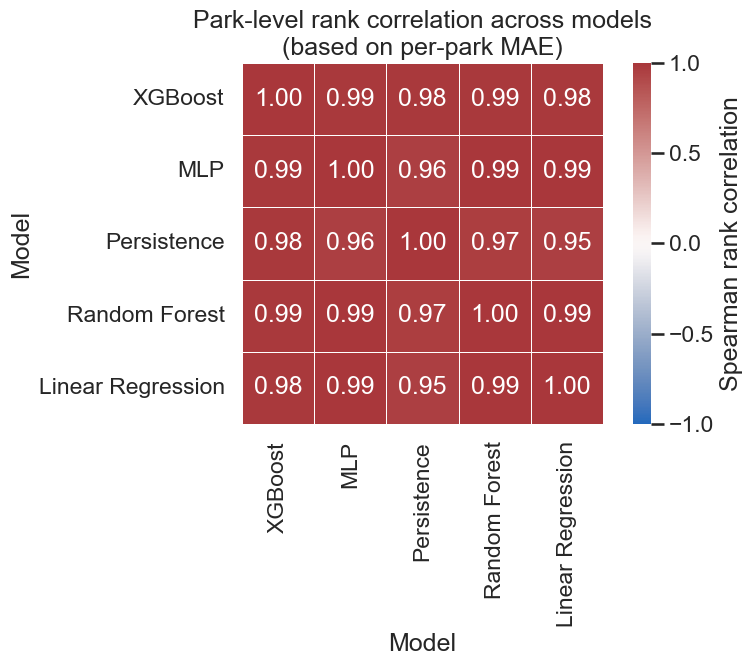

model,XGBoost,MLP,Persistence,Random Forest,Linear Regression
model,,,,,
XGBoost,1.000000,0.990592,0.984542,0.991568,0.984427
MLP,0.990592,1.000000,0.960578,0.993099,0.994145
Persistence,0.984542,0.960578,1.000000,0.968006,0.953824
Random Forest,0.991568,0.993099,0.968006,1.000000,0.992320
Linear Regression,0.984427,0.994145,0.953824,0.992320,1.000000


In [12]:
# ============================================================
# NB09 | Rank-correlation heatmap across models
# ============================================================

park_model_mae_matrix = (
    park_model_metrics_df
    .pivot(index="park_id", columns="model", values="mae")
    .reindex(columns=model_order)
)

if park_model_mae_matrix.isna().any().any():
    raise ValueError("NaN values found in park_model_mae_matrix before correlation analysis.")

# Correlation of park-level model rankings across parks
model_rank_corr_df = park_model_mae_matrix.corr(method="spearman")

plt.figure(figsize=(9, 7))
sns.heatmap(
    model_rank_corr_df,
    annot=True,
    fmt=".2f",
    cmap="vlag",
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5,
    cbar_kws={"label": "Spearman rank correlation"},
)
plt.title("Park-level rank correlation across models\n(based on per-park MAE)")
plt.xlabel("Model")
plt.ylabel("Model")
plt.tight_layout()
plt.show()

display(model_rank_corr_df)

## Deterministic case-study selection logic

Στο επόμενο βήμα, ο στόχος δεν είναι να επιλεγούν «τυχαία ενδιαφέροντα parks», αλλά να δημιουργηθεί ένα **deterministic και reproducible case-study cohort** περίπου 10 parks για thesis-ready figures και park-level interpretation.

### Αρχές επιλογής

Η επιλογή πρέπει να καλύπτει διαφορετικές διαγνωστικές όψεις του benchmark space:

- **easy parks**  
  parks όπου τουλάχιστον ένα model επιτυγχάνει πολύ χαμηλό σφάλμα

- **hard parks**  
  parks όπου ακόμη και το καλύτερο model παραμένει με υψηλό σφάλμα

- **high-bias parks**  
  parks με συστηματική signed απόκλιση, άρα εντονότερη tendency για underprediction ή overprediction

- **high-spread parks**  
  parks με μεγάλη residual variability, άρα πιο ασταθή error structure

### Γιατί deterministic selection

Η deterministic selection είναι σημαντική για:

- reproducibility
- thesis consistency
- καθαρή τεκμηρίωση
- αποφυγή ad hoc επιλογών με βάση οπτική προτίμηση

### Μεθοδολογικό όριο

Το selected cohort δεν πρέπει να παρουσιάζεται ως:

- anomaly set
- faulty turbine set
- health-labeled subset

Αποτελεί **diagnostic case-study cohort** μέσα στο forecasting residual space.

In [13]:
# ============================================================
# NB09 | Automatic selection περίπου 10 parks
# ============================================================

TARGET_SELECTED_PARKS = 10

CATEGORY_PRIORITY = {
    "hard": 1,
    "high_bias": 2,
    "high_spread": 3,
    "easy": 4,
    "mid_band_fill": 5,
}

CATEGORY_QUOTAS = {
    "hard": 3,
    "high_bias": 3,
    "high_spread": 2,
    "easy": 2,
}


def build_case_study_candidate_table() -> pd.DataFrame:
    candidate_frames = []

    source_map = {
        "hard": hard_parks_df,
        "high_bias": high_bias_parks_df,
        "high_spread": high_spread_parks_df,
        "easy": easy_parks_df,
    }

    for category_name, source_df in source_map.items():
        quota = CATEGORY_QUOTAS[category_name]
        tmp = source_df.head(quota).copy()
        tmp["selection_category"] = category_name
        tmp["category_priority"] = CATEGORY_PRIORITY[category_name]
        candidate_frames.append(tmp)

    candidate_df = pd.concat(candidate_frames, axis=0, ignore_index=True)

    # deterministic de-duplication:
    # πρώτα category priority, μετά καλύτερο/worse metric depending on category, μετά park_id
    candidate_df["category_sort_metric"] = np.where(
        candidate_df["selection_category"].eq("easy"),
        candidate_df["best_mae"],
        -candidate_df["best_mae"],
    )

    candidate_df = candidate_df.sort_values(
        ["category_priority", "category_sort_metric", "park_id"],
        ascending=[True, True, True],
        kind="mergesort",
    ).reset_index(drop=True)

    candidate_df = candidate_df.drop_duplicates(subset=["park_id"], keep="first").reset_index(drop=True)

    return candidate_df


def build_mid_band_fill_pool(exclude_park_ids: set[str], n_needed: int) -> pd.DataFrame:
    """
    Γεμίζει deterministic το cohort με parks από το μεσαίο performance band,
    ώστε το final set να μη συγκεντρώνεται μόνο στα άκρα.
    """
    if n_needed <= 0:
        return pd.DataFrame(columns=park_difficulty_df.columns.tolist() + ["selection_category", "category_priority"])

    tmp = park_difficulty_df.copy()

    # median-centered fill using distance from global median best_mae
    global_median_best_mae = float(tmp["best_mae"].median())
    tmp["distance_to_global_median_best_mae"] = (tmp["best_mae"] - global_median_best_mae).abs()

    tmp = tmp[~tmp["park_id"].isin(exclude_park_ids)].copy()

    tmp = tmp.sort_values(
        ["distance_to_global_median_best_mae", "mean_abs_bias", "park_id"],
        ascending=[True, False, True],
        kind="mergesort",
    ).head(n_needed).reset_index(drop=True)

    tmp["selection_category"] = "mid_band_fill"
    tmp["category_priority"] = CATEGORY_PRIORITY["mid_band_fill"]

    return tmp


auto_candidate_df = build_case_study_candidate_table()

selected_so_far = set(auto_candidate_df["park_id"].tolist())
n_missing = TARGET_SELECTED_PARKS - len(auto_candidate_df)

mid_band_fill_df = build_mid_band_fill_pool(
    exclude_park_ids=selected_so_far,
    n_needed=n_missing,
)

auto_selected_parks_df = pd.concat(
    [auto_candidate_df, mid_band_fill_df],
    axis=0,
    ignore_index=True,
)

auto_selected_parks_df = auto_selected_parks_df.sort_values(
    ["category_priority", "park_id"],
    kind="mergesort",
).reset_index(drop=True)

auto_selected_parks_df["selection_order"] = np.arange(1, len(auto_selected_parks_df) + 1)

if auto_selected_parks_df["park_id"].duplicated().any():
    dup_count = int(auto_selected_parks_df["park_id"].duplicated().sum())
    raise ValueError(f"Duplicate parks found in auto_selected_parks_df: {dup_count}")

if len(auto_selected_parks_df) != TARGET_SELECTED_PARKS:
    raise ValueError(
        f"Automatic case-study selection did not reach target size. "
        f"Expected={TARGET_SELECTED_PARKS}, Found={len(auto_selected_parks_df)}"
    )

AUTO_SELECTED_PARKS = auto_selected_parks_df["park_id"].tolist()

print("Automatic case-study selection completed.")
print(f"AUTO_SELECTED_PARKS = {AUTO_SELECTED_PARKS}")

display(
    auto_selected_parks_df[
        [
            "selection_order",
            "selection_category",
            "park_id",
            "best_model_by_mae",
            "best_mae",
            "median_mae",
            "max_abs_bias",
            "mean_residual_std",
        ]
    ]
)

Automatic case-study selection completed.
AUTO_SELECTED_PARKS = ['02985', '05078', '05792', '02483', '02961', '05426', '01550', '02559', '01078', '05906']


,selection_order,selection_category,park_id,best_model_by_mae,best_mae,median_mae,max_abs_bias,mean_residual_std
0,1,hard,02985,MLP,0.111843,0.115043,0.030641,0.179469
1,2,hard,05078,Persistence,0.113020,0.115663,0.007244,0.177636
2,3,hard,05792,Persistence,0.112495,0.124590,0.027825,0.179330
3,4,high_bias,02483,XGBoost,0.097154,0.102272,0.045889,0.144243
4,5,high_bias,02961,Persistence,0.069237,0.090769,0.043279,0.138707
5,6,high_bias,05426,Persistence,0.097831,0.113958,0.057499,0.163821
6,7,easy,01550,Persistence,0.016214,0.025435,0.031601,0.050013
7,8,easy,02559,Persistence,0.022387,0.026856,0.027451,0.060023
8,9,mid_band_fill,01078,XGBoost,0.065456,0.070031,0.010526,0.115599
9,10,mid_band_fill,05906,XGBoost,0.065866,0.068605,0.006919,0.120918


In [14]:
# ============================================================
# NB09 | Manual thesis-oriented override
# ============================================================

# Προεπιλογή: κρατάμε το deterministic automatic cohort.
# Αν αργότερα θέλεις thesis-oriented override, αλλάζεις μόνο αυτή τη λίστα.
MANUAL_SELECTED_PARKS = AUTO_SELECTED_PARKS.copy()

# Παράδειγμα μελλοντικού override:
# MANUAL_SELECTED_PARKS = [
#     "05078", "05426", "02985", "05792", "04271",
#     "01550", "07341", "06211", "02483", "00701",
# ]

if len(MANUAL_SELECTED_PARKS) != TARGET_SELECTED_PARKS:
    raise ValueError(
        f"MANUAL_SELECTED_PARKS must contain exactly {TARGET_SELECTED_PARKS} parks. "
        f"Found={len(MANUAL_SELECTED_PARKS)}"
    )

if len(set(MANUAL_SELECTED_PARKS)) != len(MANUAL_SELECTED_PARKS):
    raise ValueError("MANUAL_SELECTED_PARKS contains duplicates.")

unknown_manual_parks = sorted(set(MANUAL_SELECTED_PARKS) - set(park_difficulty_df["park_id"]))
if unknown_manual_parks:
    raise ValueError(f"Unknown park_ids in MANUAL_SELECTED_PARKS: {unknown_manual_parks}")

selected_park_ids = MANUAL_SELECTED_PARKS.copy()

selected_parks_control_df = pd.DataFrame(
    {
        "selection_order": np.arange(1, len(selected_park_ids) + 1),
        "park_id": selected_park_ids,
        "selection_source": [
            "manual_override" if MANUAL_SELECTED_PARKS != AUTO_SELECTED_PARKS else "automatic_default"
        ] * len(selected_park_ids),
    }
)

print("Final selected park cohort established.")
display(selected_parks_control_df)

Final selected park cohort established.


,selection_order,park_id,selection_source
0,1,02985,automatic_default
1,2,05078,automatic_default
2,3,05792,automatic_default
3,4,02483,automatic_default
4,5,02961,automatic_default
5,6,05426,automatic_default
6,7,01550,automatic_default
7,8,02559,automatic_default
8,9,01078,automatic_default
9,10,05906,automatic_default


In [15]:
# ============================================================
# NB09 | Selected park overview + export
# ============================================================

selected_park_overview_df = (
    selected_parks_control_df
    .merge(
        auto_selected_parks_df[
            [
                "park_id",
                "selection_category",
                "best_model_by_mae",
                "best_mae",
                "median_mae",
                "mean_mae",
                "worst_mae",
                "mean_abs_bias",
                "max_abs_bias",
                "mean_residual_std",
            ]
        ],
        on="park_id",
        how="left",
        validate="one_to_one",
    )
    .sort_values("selection_order", kind="mergesort")
    .reset_index(drop=True)
)

# Αν κάποιο selected park ήρθε από manual override αλλά δεν ήταν στο auto set,
# φέρνουμε deterministic fallback info από park_difficulty_df / park_best_model_df.
missing_category_mask = selected_park_overview_df["selection_category"].isna()

if missing_category_mask.any():
    fallback_df = (
        park_difficulty_df
        .merge(
            park_best_model_df[["park_id", "best_model_by_mae"]],
            on="park_id",
            how="left",
            validate="one_to_one",
        )
        .copy()
    )
    fallback_df["selection_category"] = "manual_only"

    selected_park_overview_df = (
        selected_park_overview_df.drop(
            columns=[
                "selection_category",
                "best_model_by_mae",
                "best_mae",
                "median_mae",
                "mean_mae",
                "worst_mae",
                "mean_abs_bias",
                "max_abs_bias",
                "mean_residual_std",
            ]
        )
        .merge(
            fallback_df[
                [
                    "park_id",
                    "selection_category",
                    "best_model_by_mae",
                    "best_mae",
                    "median_mae",
                    "mean_mae",
                    "worst_mae",
                    "mean_abs_bias",
                    "max_abs_bias",
                    "mean_residual_std",
                ]
            ],
            on="park_id",
            how="left",
            validate="one_to_one",
        )
        .sort_values("selection_order", kind="mergesort")
        .reset_index(drop=True)
    )

selected_park_model_metrics_df = (
    park_model_metrics_df[park_model_metrics_df["park_id"].isin(selected_park_ids)]
    .copy()
    .sort_values(["park_id", "park_rank_by_mae", "model"], kind="mergesort")
    .reset_index(drop=True)
)

selected_park_overview_path = NB09_EXPORT_DIR / "nb09_selected_park_overview.csv"
selected_park_model_metrics_path = NB09_EXPORT_DIR / "nb09_selected_park_model_metrics.csv"
selected_park_ids_path = NB09_EXPORT_DIR / "nb09_selected_park_ids.csv"

selected_park_overview_df.to_csv(selected_park_overview_path, index=False)
selected_park_model_metrics_df.to_csv(selected_park_model_metrics_path, index=False)
selected_parks_control_df.to_csv(selected_park_ids_path, index=False)

print("Selected park overview exported successfully.")
print(f"- {selected_park_overview_path}")
print(f"- {selected_park_model_metrics_path}")
print(f"- {selected_park_ids_path}")

display(selected_park_overview_df)
print("Per-model metrics for selected parks:")
display(
    selected_park_model_metrics_df[
        [
            "park_id",
            "model",
            "park_rank_by_mae",
            "mae",
            "rmse",
            "mean_residual",
            "abs_bias",
            "residual_std",
        ]
    ].head(25)
)

Selected park overview exported successfully.
- C:\Users\diony\Desktop\WindPower_DigitalTwin\data\processed\diagnostics\nb09_park_level\nb09_selected_park_overview.csv
- C:\Users\diony\Desktop\WindPower_DigitalTwin\data\processed\diagnostics\nb09_park_level\nb09_selected_park_model_metrics.csv
- C:\Users\diony\Desktop\WindPower_DigitalTwin\data\processed\diagnostics\nb09_park_level\nb09_selected_park_ids.csv


,selection_order,park_id,selection_source,selection_category,best_model_by_mae,best_mae,median_mae,mean_mae,worst_mae,mean_abs_bias,max_abs_bias,mean_residual_std
0,1,02985,automatic_default,hard,MLP,0.111843,0.115043,0.114765,0.119145,0.015518,0.030641,0.179469
1,2,05078,automatic_default,hard,Persistence,0.113020,0.115663,0.117228,0.124828,0.003651,0.007244,0.177636
2,3,05792,automatic_default,hard,Persistence,0.112495,0.124590,0.122020,0.126597,0.010589,0.027825,0.179330
3,4,02483,automatic_default,high_bias,XGBoost,0.097154,0.102272,0.102055,0.108762,0.019953,0.045889,0.144243
4,5,02961,automatic_default,high_bias,Persistence,0.069237,0.090769,0.084511,0.096294,0.026244,0.043279,0.138707
5,6,05426,automatic_default,high_bias,Persistence,0.097831,0.113958,0.110837,0.121688,0.030699,0.057499,0.163821
6,7,01550,automatic_default,easy,Persistence,0.016214,0.025435,0.026047,0.041964,0.012133,0.031601,0.050013
7,8,02559,automatic_default,easy,Persistence,0.022387,0.026856,0.029275,0.035638,0.013957,0.027451,0.060023
8,9,01078,automatic_default,mid_band_fill,XGBoost,0.065456,0.070031,0.069860,0.074472,0.004412,0.010526,0.115599
9,10,05906,automatic_default,mid_band_fill,XGBoost,0.065866,0.068605,0.068742,0.071593,0.002287,0.006919,0.120918


Per-model metrics for selected parks:


,park_id,model,park_rank_by_mae,mae,rmse,mean_residual,abs_bias,residual_std
0,01078,XGBoost,1,0.065456,0.108620,0.004292,0.004292,0.108548
1,01078,MLP,2,0.066903,0.110171,0.010526,0.010526,0.109679
2,01078,Random Forest,3,0.070031,0.112961,0.001504,0.001504,0.112965
3,01078,Linear Regression,4,0.072438,0.117191,0.005737,0.005737,0.117064
4,01078,Persistence,5,0.074472,0.129723,0.000002,0.000002,0.129738
5,01550,Persistence,1,0.016214,0.046824,0.000000,0.000000,0.046830
6,01550,XGBoost,2,0.021030,0.049507,-0.007036,0.007036,0.049011
7,01550,MLP,3,0.025435,0.053272,-0.011086,0.011086,0.052112
8,01550,Random Forest,4,0.025590,0.054636,-0.010945,0.010945,0.053535
9,01550,Linear Regression,5,0.041964,0.057946,-0.031601,0.031601,0.048577


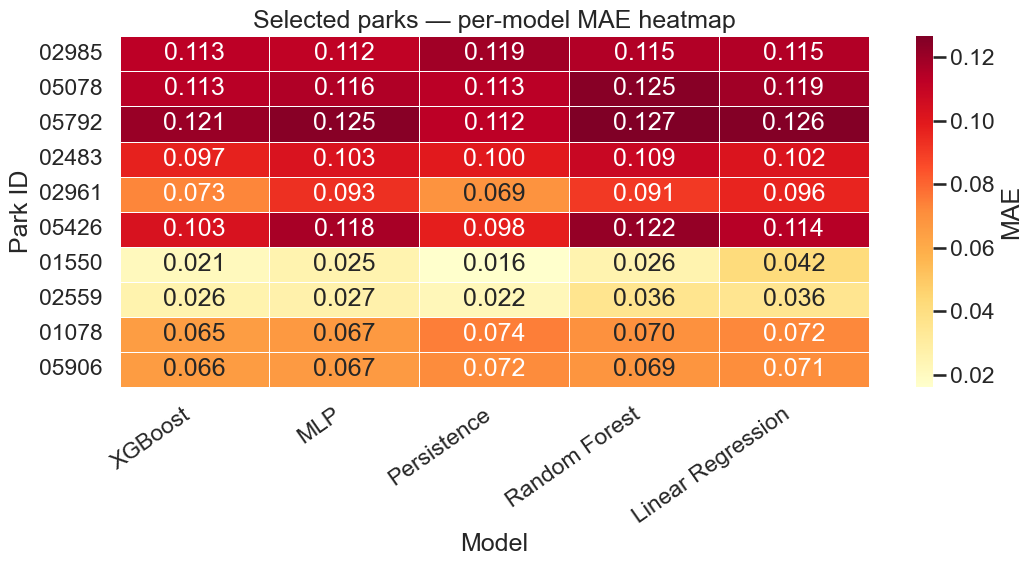

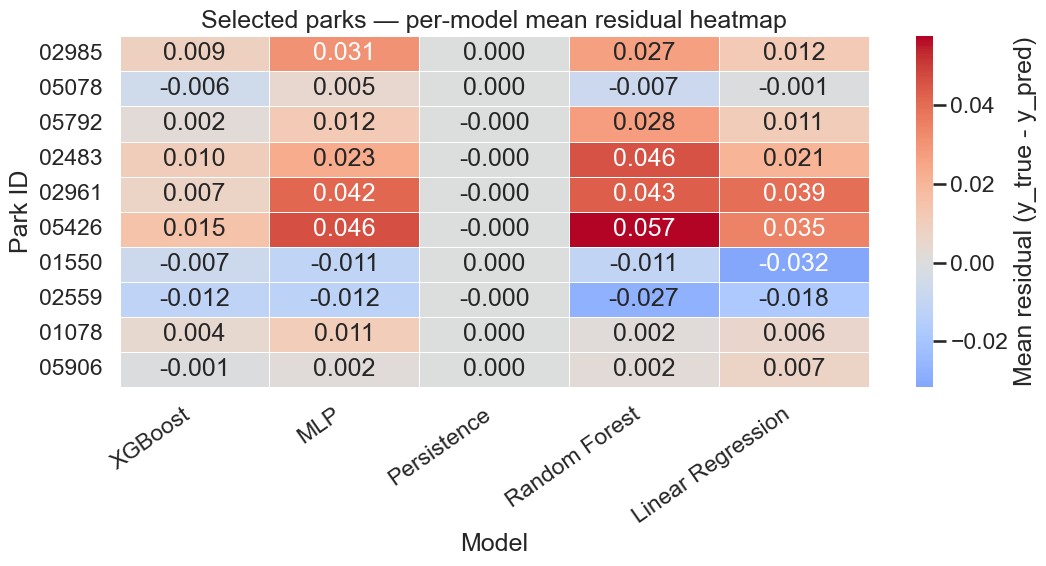

model,XGBoost,MLP,Persistence,Random Forest,Linear Regression
park_id,,,,,
02985,0.112502,0.111843,0.119145,0.115043,0.115292
05078,0.113442,0.115663,0.113020,0.124828,0.119188
05792,0.120817,0.124590,0.112495,0.126597,0.125601
02483,0.097154,0.102554,0.099534,0.108762,0.102272
02961,0.073118,0.093137,0.069237,0.090769,0.096294
05426,0.103193,0.117515,0.097831,0.121688,0.113958
01550,0.021030,0.025435,0.016214,0.025590,0.041964
02559,0.025965,0.026856,0.022387,0.035638,0.035531
01078,0.065456,0.066903,0.074472,0.070031,0.072438


model,XGBoost,MLP,Persistence,Random Forest,Linear Regression
park_id,,,,,
02985,0.008503,0.030641,0.000015,0.026862,0.011572
05078,-0.005757,0.004751,0.000002,-0.007244,-0.000503
05792,0.001926,0.012024,-0.000149,0.027825,0.011021
02483,0.010031,0.023267,-0.000021,0.045889,0.020558
02961,0.006921,0.041525,-0.000081,0.043279,0.039413
05426,0.015004,0.046138,-0.000123,0.057499,0.034732
01550,-0.007036,-0.011086,0.000000,-0.010945,-0.031601
02559,-0.011899,-0.012463,-0.000000,-0.027451,-0.017973
01078,0.004292,0.010526,0.000002,0.001504,0.005737


In [16]:
# ============================================================
# NB09 | Heatmaps για selected parks
# ============================================================

selected_mae_heatmap_df = (
    selected_park_model_metrics_df
    .pivot(index="park_id", columns="model", values="mae")
    .reindex(index=selected_park_ids, columns=model_order)
)

selected_bias_heatmap_df = (
    selected_park_model_metrics_df
    .pivot(index="park_id", columns="model", values="mean_residual")
    .reindex(index=selected_park_ids, columns=model_order)
)

if selected_mae_heatmap_df.isna().any().any():
    raise ValueError("NaN values found in selected_mae_heatmap_df.")

if selected_bias_heatmap_df.isna().any().any():
    raise ValueError("NaN values found in selected_bias_heatmap_df.")

plt.figure(figsize=(11, 6))
sns.heatmap(
    selected_mae_heatmap_df,
    annot=True,
    fmt=".3f",
    cmap="YlOrRd",
    linewidths=0.5,
    cbar_kws={"label": "MAE"},
)
plt.title("Selected parks — per-model MAE heatmap")
plt.xlabel("Model")
plt.ylabel("Park ID")
plt.xticks(rotation=35, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

plt.figure(figsize=(11, 6))
sns.heatmap(
    selected_bias_heatmap_df,
    annot=True,
    fmt=".3f",
    cmap="coolwarm",
    center=0.0,
    linewidths=0.5,
    cbar_kws={"label": "Mean residual (y_true - y_pred)"},
)
plt.title("Selected parks — per-model mean residual heatmap")
plt.xlabel("Model")
plt.ylabel("Park ID")
plt.xticks(rotation=35, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

display(selected_mae_heatmap_df)
display(selected_bias_heatmap_df)

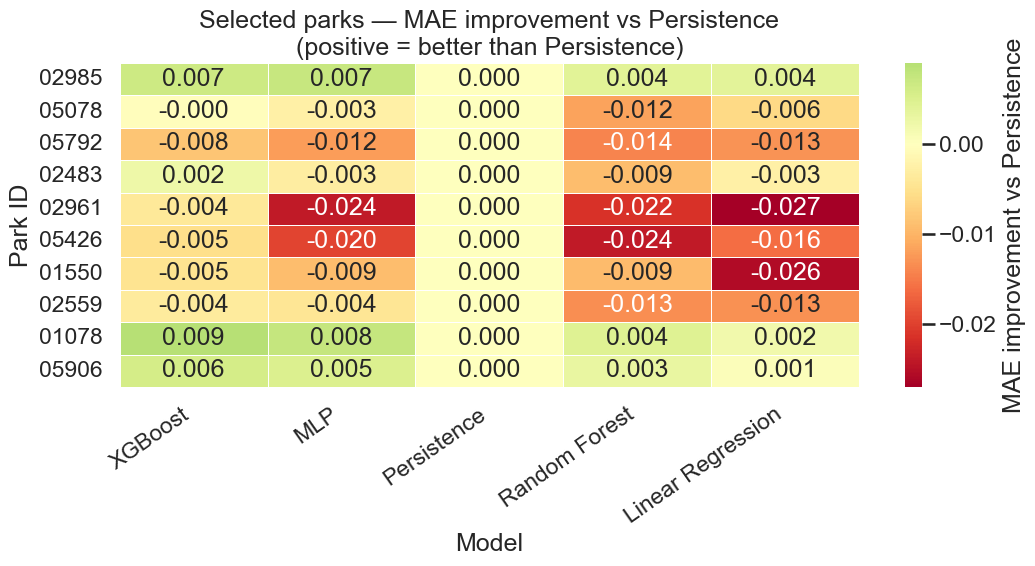

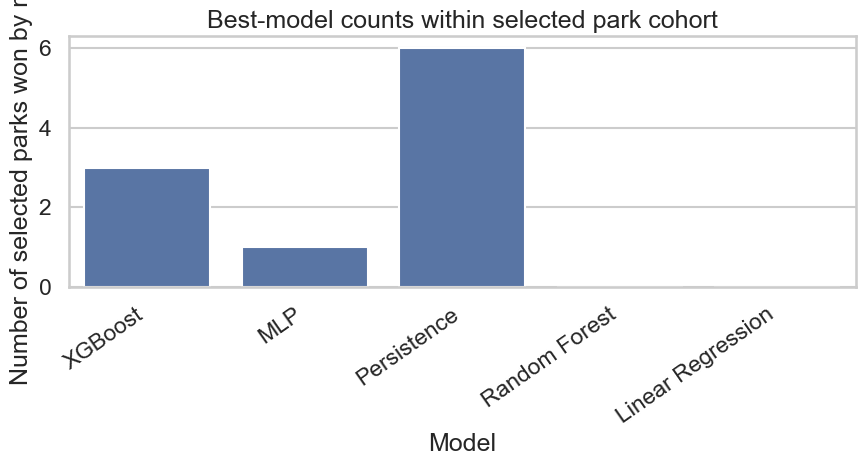

model,XGBoost,MLP,Persistence,Random Forest,Linear Regression
park_id,,,,,
02985,0.006642,0.007302,0.000000,0.004102,0.003853
05078,-0.000422,-0.002643,0.000000,-0.011808,-0.006168
05792,-0.008321,-0.012094,0.000000,-0.014102,-0.013105
02483,0.002380,-0.003020,0.000000,-0.009229,-0.002738
02961,-0.003881,-0.023900,0.000000,-0.021532,-0.027057
05426,-0.005362,-0.019684,0.000000,-0.023858,-0.016127
01550,-0.004815,-0.009220,0.000000,-0.009375,-0.025750
02559,-0.003578,-0.004470,0.000000,-0.013251,-0.013145
01078,0.009016,0.007570,0.000000,0.004441,0.002034


,model,selected_park_count,all_park_count
0,XGBoost,3,197
1,MLP,1,28
2,Persistence,6,30
3,Random Forest,0,1
4,Linear Regression,0,0


In [17]:
# ============================================================
# NB09 | Improvement vs Persistence + best-model counts
# ============================================================

selected_metrics_wide_df = (
    selected_park_model_metrics_df
    .pivot(index="park_id", columns="model", values="mae")
    .reindex(index=selected_park_ids, columns=model_order)
)

if "Persistence" not in selected_metrics_wide_df.columns:
    raise ValueError("Persistence column is missing from selected_metrics_wide_df.")

selected_improvement_vs_persistence_df = selected_metrics_wide_df.copy()

for col in selected_improvement_vs_persistence_df.columns:
    selected_improvement_vs_persistence_df[col] = (
        selected_metrics_wide_df["Persistence"] - selected_metrics_wide_df[col]
    )

# Η Persistence σε σχέση με τον εαυτό της είναι μηδέν
selected_improvement_vs_persistence_df["Persistence"] = 0.0

plt.figure(figsize=(11, 6))
sns.heatmap(
    selected_improvement_vs_persistence_df,
    annot=True,
    fmt=".3f",
    cmap="RdYlGn",
    center=0.0,
    linewidths=0.5,
    cbar_kws={"label": "MAE improvement vs Persistence"},
)
plt.title("Selected parks — MAE improvement vs Persistence\n(positive = better than Persistence)")
plt.xlabel("Model")
plt.ylabel("Park ID")
plt.xticks(rotation=35, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

selected_best_model_counts_df = (
    selected_park_overview_df["best_model_by_mae"]
    .value_counts()
    .reindex(model_order, fill_value=0)
    .rename_axis("model")
    .reset_index(name="selected_park_count")
)

overall_best_model_counts_df = (
    park_best_model_df["best_model_by_mae"]
    .value_counts()
    .reindex(model_order, fill_value=0)
    .rename_axis("model")
    .reset_index(name="all_park_count")
)

best_model_counts_df = selected_best_model_counts_df.merge(
    overall_best_model_counts_df,
    on="model",
    how="left",
    validate="one_to_one",
)

plt.figure(figsize=(9, 5))
sns.barplot(
    data=best_model_counts_df,
    x="model",
    y="selected_park_count",
    order=model_order,
)
plt.title("Best-model counts within selected park cohort")
plt.xlabel("Model")
plt.ylabel("Number of selected parks won by model")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

display(selected_improvement_vs_persistence_df)
display(best_model_counts_df)

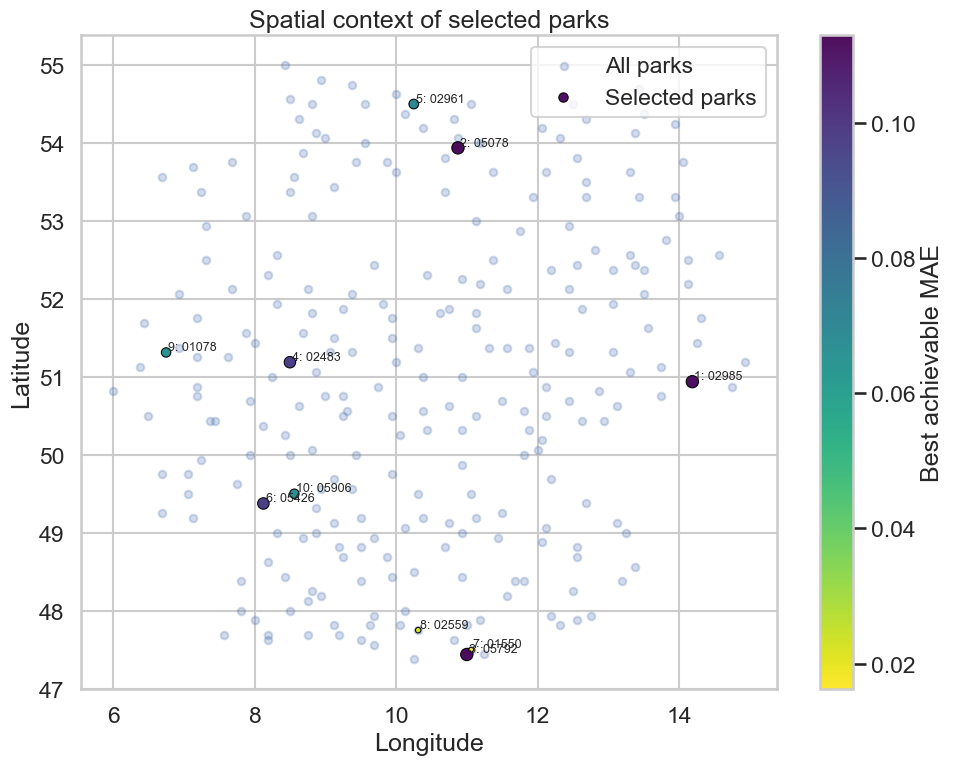

,selection_order,park_id,selection_category,best_model_by_mae,best_mae,lat,long
0,1,02985,hard,MLP,0.111843,50.937500,14.187500
1,2,05078,hard,Persistence,0.113020,53.937500,10.875000
2,3,05792,hard,Persistence,0.112495,47.437500,11.000000
3,4,02483,high_bias,XGBoost,0.097154,51.187500,8.500000
4,5,02961,high_bias,Persistence,0.069237,54.500000,10.250000
5,6,05426,high_bias,Persistence,0.097831,49.375000,8.125000
6,7,01550,easy,Persistence,0.016214,47.500000,11.062500
7,8,02559,easy,Persistence,0.022387,47.750000,10.312500
8,9,01078,mid_band_fill,XGBoost,0.065456,51.312500,6.750000
9,10,05906,mid_band_fill,XGBoost,0.065866,49.500000,8.562500


In [18]:
# ============================================================
# NB09 | Spatial scatter / spatial context
# ============================================================

meta_spatial_df = meta_df.copy().rename(columns={"loc_id": "park_id"})

all_parks_spatial_df = (
    park_difficulty_df
    .merge(
        meta_spatial_df[["park_id", "lat", "long"]],
        on="park_id",
        how="inner",
        validate="one_to_one",
    )
    .merge(
        park_best_model_df[["park_id", "best_model_by_mae"]],
        on="park_id",
        how="left",
        validate="one_to_one",
    )
)

selected_spatial_df = (
    selected_park_overview_df
    .merge(
        meta_spatial_df[["park_id", "lat", "long"]],
        on="park_id",
        how="left",
        validate="one_to_one",
    )
    .sort_values("selection_order", kind="mergesort")
    .reset_index(drop=True)
)

missing_selected_coords = selected_spatial_df[["lat", "long"]].isna().any(axis=1).sum()
if missing_selected_coords > 0:
    raise ValueError(
        f"Missing spatial coordinates for {missing_selected_coords} selected parks."
    )

plt.figure(figsize=(10, 8))

# Background: όλα τα benchmark-ready parks
plt.scatter(
    all_parks_spatial_df["long"],
    all_parks_spatial_df["lat"],
    s=30,
    alpha=0.25,
    label="All parks",
)

# Overlay: selected parks, size by best_mae
plt.scatter(
    selected_spatial_df["long"],
    selected_spatial_df["lat"],
    s=700 * selected_spatial_df["best_mae"],
    c=selected_spatial_df["best_mae"],
    cmap="viridis_r",
    edgecolor="black",
    linewidth=0.8,
    alpha=0.95,
    label="Selected parks",
)

for _, row in selected_spatial_df.iterrows():
    plt.text(
        row["long"] + 0.03,
        row["lat"] + 0.03,
        f"{row['selection_order']}: {row['park_id']}",
        fontsize=9,
    )

cbar = plt.colorbar()
cbar.set_label("Best achievable MAE")

plt.title("Spatial context of selected parks")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend(loc="best")
plt.tight_layout()
plt.show()

display(
    selected_spatial_df[
        [
            "selection_order",
            "park_id",
            "selection_category",
            "best_model_by_mae",
            "best_mae",
            "lat",
            "long",
        ]
    ]
)

## Case-study figure design

Το επόμενο βήμα είναι η δημιουργία **thesis-ready case-study figures** για κάθε selected park.

### Τι πρέπει να δείχνει κάθε figure

Κάθε case-study figure πρέπει να είναι compact αλλά πληροφοριακά πλήρης, ώστε να λειτουργεί τόσο ερευνητικά όσο και συγγραφικά.

Για κάθε selected park, η figure πρέπει να περιλαμβάνει:

1. **time-window actual vs predicted comparison**  
   σύγκριση `y_true` με τις προβλέψεις των implemented baselines σε ένα deterministic window

2. **residual panel**  
   residual trajectories με sign convention:
   - `residual = y_true - y_pred`

3. **compact park-level context**  
   σύντομο title/subtitle με:
   - `park_id`
   - selection category
   - best model
   - best MAE
   - bias / spread context

### Γιατί deterministic window selection

Το window δεν πρέπει να επιλέγεται χειροκίνητα με οπτικό κριτήριο.  
Πρέπει να προκύπτει reproducibly από deterministic logic, ώστε:

- να αποφεύγεται cherry-picking,
- να διατηρείται scientific defensibility,
- και να μπορεί το notebook να ξανατρέξει με το ίδιο αποτέλεσμα.

### Ερμηνευτικός στόχος

Οι case-study figures δεν θα χρησιμοποιηθούν για να αποδείξουν fault events.  
Θα χρησιμοποιηθούν για να δείξουν:

- πώς αλλάζει η ποιότητα πρόβλεψης ανά park,
- πώς εμφανίζεται η bias structure,
- και πώς η forecasting residual behavior μπορεί να υποστηρίξει diagnostics-aware discussion.

In [19]:
# ============================================================
# NB09 | Helpers για deterministic case-study window selection
# ============================================================

CASE_STUDY_WINDOW_HOURS = 72
CASE_STUDY_SCORING_ROLLING_HOURS = 24
CASE_STUDY_MIN_PERIODS = 12

CASE_STUDY_FIGURE_DIR = NB09_EXPORT_DIR / "figures" / "case_studies"
CASE_STUDY_FIGURE_DIR.mkdir(parents=True, exist_ok=True)


def get_selected_park_context(park_id: str) -> pd.Series:
    row = selected_park_overview_df.loc[selected_park_overview_df["park_id"] == park_id]
    if len(row) != 1:
        raise ValueError(f"Expected exactly one selected_park_overview row for park_id={park_id}")
    return row.iloc[0]


def build_single_park_analysis_df(park_id: str) -> pd.DataFrame:
    df = (
        analysis_df.loc[analysis_df["park_id"] == park_id]
        .copy()
        .sort_values(["timestamp", "model"], kind="mergesort")
        .reset_index(drop=True)
    )

    if df.empty:
        raise ValueError(f"No analysis rows found for park_id={park_id}")

    found_models = sorted(df["model"].unique().tolist())
    if set(found_models) != set(CANONICAL_MODELS):
        raise ValueError(
            f"Park {park_id} does not contain the full canonical model set. "
            f"Found={found_models}"
        )

    per_model_counts = df.groupby("model", observed=True)["timestamp"].nunique()
    if per_model_counts.nunique() != 1:
        raise ValueError(
            f"Park {park_id} has inconsistent timestamp coverage across models: "
            f"{per_model_counts.to_dict()}"
        )

    return df


def select_deterministic_case_study_window(
    park_id: str,
    window_hours: int = CASE_STUDY_WINDOW_HOURS,
    scoring_rolling_hours: int = CASE_STUDY_SCORING_ROLLING_HOURS,
) -> tuple[pd.DataFrame, pd.DataFrame, dict]:
    """
    Επιλέγει deterministic case-study window με βάση τη δυσκολία του park
    στο συγκεκριμένο test period.

    Scoring logic:
    - υπολογίζουμε ανά timestamp το mean abs_error across models
    - κάνουμε centered rolling smoothing
    - επιλέγουμε το peak difficulty timestamp
    - ανοίγουμε fixed-size window γύρω από αυτό
    """
    park_df = build_single_park_analysis_df(park_id)

    timestamp_score_df = (
        park_df.groupby("timestamp", observed=True)
        .agg(
            y_true=("y_true", "first"),
            mean_abs_error_all_models=("abs_error", "mean"),
            max_abs_error_all_models=("abs_error", "max"),
            mean_signed_residual_all_models=("residual", "mean"),
        )
        .reset_index()
        .sort_values("timestamp", kind="mergesort")
        .reset_index(drop=True)
    )

    timestamp_score_df["difficulty_score"] = (
        timestamp_score_df["mean_abs_error_all_models"]
        .rolling(
            window=scoring_rolling_hours,
            min_periods=CASE_STUDY_MIN_PERIODS,
            center=True,
        )
        .mean()
    )

    timestamp_score_df["difficulty_score"] = timestamp_score_df["difficulty_score"].fillna(
        timestamp_score_df["mean_abs_error_all_models"]
    )

    peak_idx = int(timestamp_score_df["difficulty_score"].idxmax())
    peak_timestamp = timestamp_score_df.loc[peak_idx, "timestamp"]

    half_window = window_hours // 2
    start_ts = peak_timestamp - pd.Timedelta(hours=half_window)
    end_ts = peak_timestamp + pd.Timedelta(hours=(window_hours - half_window - 1))

    ts_min = timestamp_score_df["timestamp"].min()
    ts_max = timestamp_score_df["timestamp"].max()

    if start_ts < ts_min:
        shift = ts_min - start_ts
        start_ts = start_ts + shift
        end_ts = end_ts + shift

    if end_ts > ts_max:
        shift = end_ts - ts_max
        start_ts = start_ts - shift
        end_ts = end_ts - shift

    start_ts = max(start_ts, ts_min)
    end_ts = min(end_ts, ts_max)

    window_df = (
        park_df.loc[
            (park_df["timestamp"] >= start_ts) &
            (park_df["timestamp"] <= end_ts)
        ]
        .copy()
        .sort_values(["timestamp", "model"], kind="mergesort")
        .reset_index(drop=True)
    )

    if window_df.empty:
        raise ValueError(f"Selected window is empty for park_id={park_id}")

    context = get_selected_park_context(park_id)

    metadata = {
        "park_id": park_id,
        "selection_order": int(context["selection_order"]),
        "selection_category": context["selection_category"],
        "best_model_by_mae": context["best_model_by_mae"],
        "best_mae": float(context["best_mae"]),
        "mean_abs_bias": float(context["mean_abs_bias"]),
        "max_abs_bias": float(context["max_abs_bias"]),
        "mean_residual_std": float(context["mean_residual_std"]),
        "window_hours": int(window_hours),
        "rolling_hours": int(scoring_rolling_hours),
        "peak_timestamp": peak_timestamp,
        "window_start": start_ts,
        "window_end": end_ts,
        "peak_difficulty_score": float(timestamp_score_df.loc[peak_idx, "difficulty_score"]),
        "n_window_rows": int(len(window_df)),
        "n_window_timestamps": int(window_df["timestamp"].nunique()),
    }

    return window_df, timestamp_score_df, metadata


print("Case-study window helper layer initialized.")

Case-study window helper layer initialized.


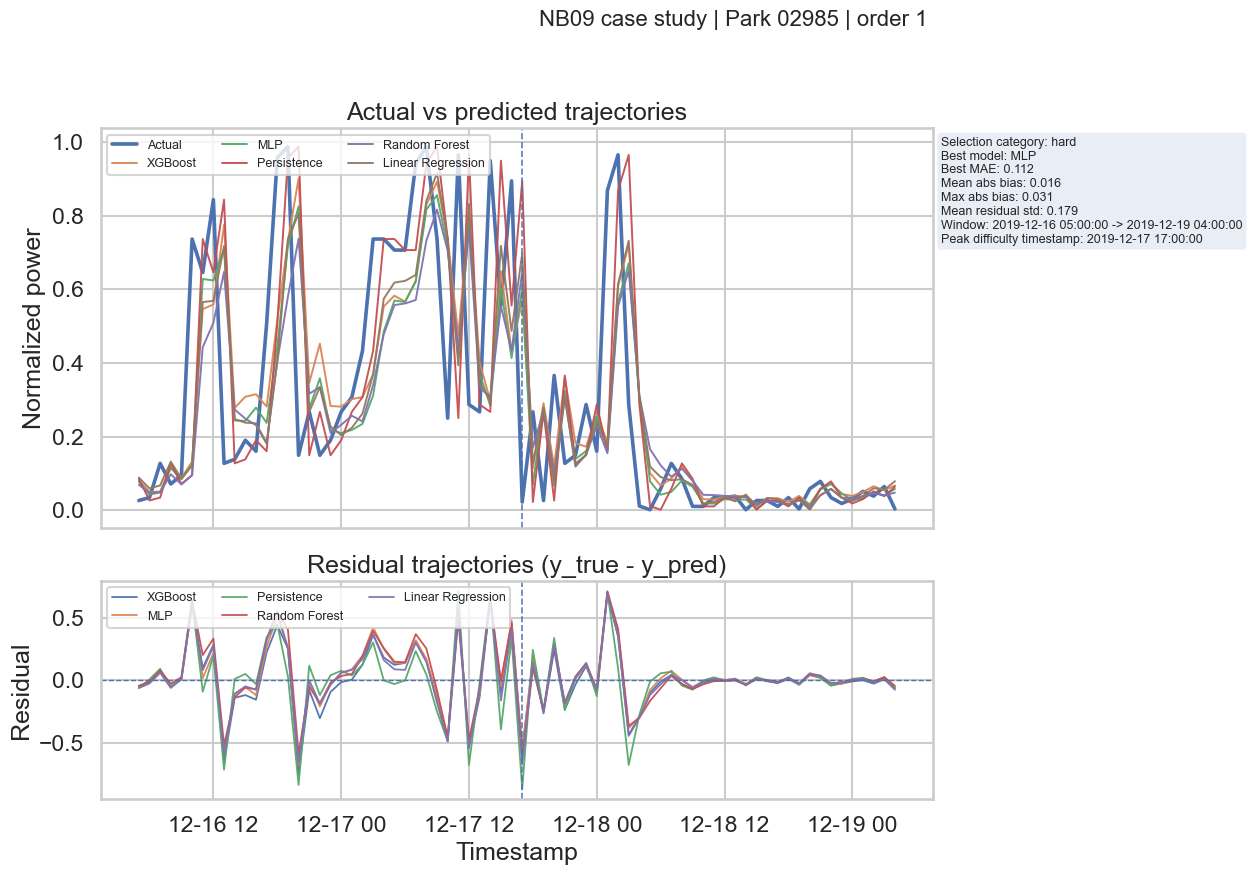

,park_id,selection_order,selection_category,best_model_by_mae,best_mae,mean_abs_bias,max_abs_bias,mean_residual_std,window_hours,rolling_hours,peak_timestamp,window_start,window_end,peak_difficulty_score,n_window_rows,n_window_timestamps
0,02985,1,hard,MLP,0.111843,0.015518,0.030641,0.179469,72,24,2019-12-17 17:00:00,2019-12-16 05:00:00,2019-12-19 04:00:00,0.305496,360,72


In [20]:
# ============================================================
# NB09 | Thesis-ready case-study figure generator for one park
# ============================================================

def plot_single_park_case_study_figure(
    park_id: str,
    window_hours: int = CASE_STUDY_WINDOW_HOURS,
    scoring_rolling_hours: int = CASE_STUDY_SCORING_ROLLING_HOURS,
    show_figure: bool = True,
):
    window_df, timestamp_score_df, metadata = select_deterministic_case_study_window(
        park_id=park_id,
        window_hours=window_hours,
        scoring_rolling_hours=scoring_rolling_hours,
    )

    actual_df = (
        window_df[["timestamp", "y_true"]]
        .drop_duplicates(subset=["timestamp"])
        .sort_values("timestamp", kind="mergesort")
        .reset_index(drop=True)
    )

    fig, axes = plt.subplots(
        2,
        1,
        figsize=(15, 9),
        sharex=True,
        gridspec_kw={"height_ratios": [2.2, 1.2]},
    )

    # Panel 1: actual vs predicted
    axes[0].plot(
        actual_df["timestamp"],
        actual_df["y_true"],
        linewidth=2.6,
        label="Actual",
    )

    for model_name in model_order:
        model_df = (
            window_df.loc[window_df["model"] == model_name]
            .sort_values("timestamp", kind="mergesort")
            .reset_index(drop=True)
        )
        axes[0].plot(
            model_df["timestamp"],
            model_df["y_pred"],
            linewidth=1.4,
            alpha=0.95,
            label=model_name,
        )

    axes[0].axvline(
        metadata["peak_timestamp"],
        linestyle="--",
        linewidth=1.2,
        alpha=0.9,
    )

    axes[0].set_ylabel("Normalized power")
    axes[0].set_title("Actual vs predicted trajectories")

    # Panel 2: residuals
    for model_name in model_order:
        model_df = (
            window_df.loc[window_df["model"] == model_name]
            .sort_values("timestamp", kind="mergesort")
            .reset_index(drop=True)
        )
        axes[1].plot(
            model_df["timestamp"],
            model_df["residual"],
            linewidth=1.3,
            alpha=0.95,
            label=model_name,
        )

    axes[1].axhline(
        0.0,
        linestyle="--",
        linewidth=1.0,
    )
    axes[1].axvline(
        metadata["peak_timestamp"],
        linestyle="--",
        linewidth=1.2,
        alpha=0.9,
    )

    axes[1].set_ylabel("Residual")
    axes[1].set_xlabel("Timestamp")
    axes[1].set_title("Residual trajectories (y_true - y_pred)")

    context_text = (
        f"Selection category: {metadata['selection_category']}\n"
        f"Best model: {metadata['best_model_by_mae']}\n"
        f"Best MAE: {metadata['best_mae']:.3f}\n"
        f"Mean abs bias: {metadata['mean_abs_bias']:.3f}\n"
        f"Max abs bias: {metadata['max_abs_bias']:.3f}\n"
        f"Mean residual std: {metadata['mean_residual_std']:.3f}\n"
        f"Window: {metadata['window_start']} -> {metadata['window_end']}\n"
        f"Peak difficulty timestamp: {metadata['peak_timestamp']}"
    )

    axes[0].text(
        1.01,
        0.98,
        context_text,
        transform=axes[0].transAxes,
        va="top",
        fontsize=9,
        bbox=dict(boxstyle="round", alpha=0.12),
    )

    axes[0].legend(loc="upper left", ncol=3, fontsize=9)
    axes[1].legend(loc="upper left", ncol=3, fontsize=9)

    fig.suptitle(
        f"NB09 case study | Park {park_id} | order {metadata['selection_order']}",
        fontsize=16,
        y=0.98,
    )

    fig.tight_layout(rect=[0, 0, 0.86, 0.96])

    if show_figure:
        plt.show()

    return fig, window_df, metadata


# Demo preview για έναν park
DEMO_PARK_ID = selected_park_ids[0]

demo_fig, demo_window_df, demo_case_study_metadata = plot_single_park_case_study_figure(
    park_id=DEMO_PARK_ID,
    show_figure=True,
)

display(pd.DataFrame([demo_case_study_metadata]))

In [21]:
# ============================================================
# NB09 | Loop για all selected case-study figures
# ============================================================

case_study_export_records = []

for park_id in selected_park_ids:
    fig, park_window_df, metadata = plot_single_park_case_study_figure(
        park_id=park_id,
        show_figure=False,
    )

    figure_path = CASE_STUDY_FIGURE_DIR / (
        f"nb09_case_study_{metadata['selection_order']:02d}_{park_id}.png"
    )

    fig.savefig(figure_path, dpi=300, bbox_inches="tight")
    plt.close(fig)

    export_record = metadata.copy()
    export_record["figure_path"] = str(figure_path)
    export_record["n_models"] = int(park_window_df["model"].nunique())
    case_study_export_records.append(export_record)

case_study_window_metadata_df = (
    pd.DataFrame(case_study_export_records)
    .sort_values(["selection_order", "park_id"], kind="mergesort")
    .reset_index(drop=True)
)

case_study_window_metadata_path = (
    NB09_EXPORT_DIR / "nb09_case_study_window_metadata.csv"
)
case_study_window_metadata_df.to_csv(case_study_window_metadata_path, index=False)

print("All selected case-study figures exported successfully.")
print(f"Case-study figure directory: {CASE_STUDY_FIGURE_DIR}")
print(f"Window metadata path       : {case_study_window_metadata_path}")

display(case_study_window_metadata_df)

All selected case-study figures exported successfully.
Case-study figure directory: C:\Users\diony\Desktop\WindPower_DigitalTwin\data\processed\diagnostics\nb09_park_level\figures\case_studies
Window metadata path       : C:\Users\diony\Desktop\WindPower_DigitalTwin\data\processed\diagnostics\nb09_park_level\nb09_case_study_window_metadata.csv


,park_id,selection_order,selection_category,best_model_by_mae,best_mae,mean_abs_bias,max_abs_bias,mean_residual_std,window_hours,rolling_hours,peak_timestamp,window_start,window_end,peak_difficulty_score,n_window_rows,n_window_timestamps,figure_path,n_models
0,02985,1,hard,MLP,0.111843,0.015518,0.030641,0.179469,72,24,2019-12-17 17:00:00,2019-12-16 05:00:00,2019-12-19 04:00:00,0.305496,360,72,C:\Users\diony\Desktop\WindPower_DigitalTwin\d...,5
1,05078,2,hard,Persistence,0.113020,0.003651,0.007244,0.177636,72,24,2020-02-10 14:00:00,2020-02-09 02:00:00,2020-02-12 01:00:00,0.309883,360,72,C:\Users\diony\Desktop\WindPower_DigitalTwin\d...,5
2,05792,3,hard,Persistence,0.112495,0.010589,0.027825,0.179330,72,24,2020-05-12 02:00:00,2020-05-10 14:00:00,2020-05-13 13:00:00,0.261825,360,72,C:\Users\diony\Desktop\WindPower_DigitalTwin\d...,5
3,02483,4,high_bias,XGBoost,0.097154,0.019953,0.045889,0.144243,72,24,2019-12-17 07:00:00,2019-12-15 19:00:00,2019-12-18 18:00:00,0.236137,360,72,C:\Users\diony\Desktop\WindPower_DigitalTwin\d...,5
4,02961,5,high_bias,Persistence,0.069237,0.026244,0.043279,0.138707,72,24,2020-05-01 09:00:00,2020-04-29 21:00:00,2020-05-02 20:00:00,0.278117,360,72,C:\Users\diony\Desktop\WindPower_DigitalTwin\d...,5
5,05426,6,high_bias,Persistence,0.097831,0.030699,0.057499,0.163821,72,24,2019-12-12 19:00:00,2019-12-11 07:00:00,2019-12-14 06:00:00,0.272481,360,72,C:\Users\diony\Desktop\WindPower_DigitalTwin\d...,5
6,01550,7,easy,Persistence,0.016214,0.012133,0.031601,0.050013,72,24,2020-02-23 18:00:00,2020-02-22 06:00:00,2020-02-25 05:00:00,0.166303,360,72,C:\Users\diony\Desktop\WindPower_DigitalTwin\d...,5
7,02559,8,easy,Persistence,0.022387,0.013957,0.027451,0.060023,72,24,2020-02-11 14:00:00,2020-02-10 02:00:00,2020-02-13 01:00:00,0.224884,360,72,C:\Users\diony\Desktop\WindPower_DigitalTwin\d...,5
8,01078,9,mid_band_fill,XGBoost,0.065456,0.004412,0.010526,0.115599,72,24,2020-02-25 19:00:00,2020-02-24 07:00:00,2020-02-27 06:00:00,0.222760,360,72,C:\Users\diony\Desktop\WindPower_DigitalTwin\d...,5
9,05906,10,mid_band_fill,XGBoost,0.065866,0.002287,0.006919,0.120918,72,24,2020-03-13 07:00:00,2020-03-11 19:00:00,2020-03-14 18:00:00,0.254982,360,72,C:\Users\diony\Desktop\WindPower_DigitalTwin\d...,5


In [22]:
# ============================================================
# NB09 | Export NB09 artifacts
# ============================================================

nb09_export_frames = {
    "nb09_park_model_metrics.csv": park_model_metrics_df,
    "nb09_park_difficulty_summary.csv": park_difficulty_df,
    "nb09_park_best_model_summary.csv": park_best_model_df,
    "nb09_model_rank_correlation.csv": model_rank_corr_df.reset_index(),
    "nb09_selected_mae_heatmap_matrix.csv": selected_mae_heatmap_df.reset_index(),
    "nb09_selected_bias_heatmap_matrix.csv": selected_bias_heatmap_df.reset_index(),
    "nb09_selected_improvement_vs_persistence.csv": selected_improvement_vs_persistence_df.reset_index(),
    "nb09_selected_best_model_counts.csv": best_model_counts_df,
    "nb09_selected_spatial_context.csv": selected_spatial_df,
    "nb09_case_study_window_metadata.csv": case_study_window_metadata_df,
}

export_manifest_records = []

for file_name, df_obj in nb09_export_frames.items():
    export_path = NB09_EXPORT_DIR / file_name
    df_obj.to_csv(export_path, index=False)

    export_manifest_records.append(
        {
            "file_name": file_name,
            "path": str(export_path),
            "rows": int(df_obj.shape[0]),
            "cols": int(df_obj.shape[1]),
        }
    )

# Προσθέτουμε και τα ήδη exported selected cohort files
preexisting_exports = [
    selected_park_overview_path,
    selected_park_model_metrics_path,
    selected_park_ids_path,
]

for existing_path in preexisting_exports:
    export_manifest_records.append(
        {
            "file_name": existing_path.name,
            "path": str(existing_path),
            "rows": np.nan,
            "cols": np.nan,
        }
    )

nb09_export_manifest_df = (
    pd.DataFrame(export_manifest_records)
    .sort_values("file_name", kind="mergesort")
    .reset_index(drop=True)
)

nb09_export_manifest_path = NB09_EXPORT_DIR / "nb09_export_manifest.csv"
nb09_export_manifest_df.to_csv(nb09_export_manifest_path, index=False)

print("NB09 artifact export completed successfully.")
print(f"Export manifest path: {nb09_export_manifest_path}")

display(nb09_export_manifest_df)

NB09 artifact export completed successfully.
Export manifest path: C:\Users\diony\Desktop\WindPower_DigitalTwin\data\processed\diagnostics\nb09_park_level\nb09_export_manifest.csv


,file_name,path,rows,cols
0,nb09_case_study_window_metadata.csv,C:\Users\diony\Desktop\WindPower_DigitalTwin\d...,10.000000,18.000000
1,nb09_model_rank_correlation.csv,C:\Users\diony\Desktop\WindPower_DigitalTwin\d...,5.000000,6.000000
2,nb09_park_best_model_summary.csv,C:\Users\diony\Desktop\WindPower_DigitalTwin\d...,256.000000,22.000000
3,nb09_park_difficulty_summary.csv,C:\Users\diony\Desktop\WindPower_DigitalTwin\d...,256.000000,9.000000
4,nb09_park_model_metrics.csv,C:\Users\diony\Desktop\WindPower_DigitalTwin\d...,"1,280.000000",22.000000
5,nb09_selected_best_model_counts.csv,C:\Users\diony\Desktop\WindPower_DigitalTwin\d...,5.000000,3.000000
6,nb09_selected_bias_heatmap_matrix.csv,C:\Users\diony\Desktop\WindPower_DigitalTwin\d...,10.000000,6.000000
7,nb09_selected_improvement_vs_persistence.csv,C:\Users\diony\Desktop\WindPower_DigitalTwin\d...,10.000000,6.000000
8,nb09_selected_mae_heatmap_matrix.csv,C:\Users\diony\Desktop\WindPower_DigitalTwin\d...,10.000000,6.000000
9,nb09_selected_park_ids.csv,C:\Users\diony\Desktop\WindPower_DigitalTwin\d...,NaN,NaN


## Scientific interpretation

Το `NB09` επεκτείνει το diagnostics layer από το row-level residual space σε **park-level diagnostic consolidation** πάνω στο κοινό **test-only evaluation space**.

### Κύρια ευρήματα του park-level layer

1. **Η σχετική δυσκολία των parks είναι σε μεγάλο βαθμό σταθερή across models.**  
   Η πολύ υψηλή rank correlation μεταξύ των implemented baselines δείχνει ότι αρκετά parks είναι συστηματικά εύκολα ή δύσκολα ανεξάρτητα από το ποιο model χρησιμοποιείται.

2. **Το aggregate benchmark δεν αρκεί για πλήρη ερμηνεία.**  
   Παρότι το `baseline_metrics.csv` παραμένει η canonical authority για τη συνολική cross-model ranking, το park-level layer δείχνει ότι η απόδοση των μοντέλων μεταβάλλεται ουσιαστικά ανά park και ότι η model superiority δεν είναι ομοιόμορφη σε όλο το spatial cohort.

3. **Υπάρχουν parks με έντονη bias structure και parks με υψηλή residual spread.**  
   Αυτό ενισχύει την άποψη ότι τα forecasting errors δεν είναι μόνο τυχαίος θόρυβος, αλλά εμφανίζουν δομημένη συμπεριφορά που αξίζει να μελετηθεί σε πιο λεπτομερές diagnostic επίπεδο.

4. **Το Persistence παραμένει ισχυρό reference σε συγκεκριμένα parks.**  
   Το εύρημα αυτό δεν αναιρεί το συνολικό benchmark ranking. Αντίθετα, δείχνει ότι σε ορισμένα parks η local temporal continuity είναι τόσο ισχυρή ώστε ένα απλό reference model να παραμένει ανταγωνιστικό ακόμη και απέναντι σε πιο σύνθετα tabular baselines.

5. **Το selected case-study cohort είναι διαγνωστικά χρήσιμο και όχι τυχαίο.**  
   Η deterministic selection συνδυάζει hard, high-bias, easy και mid-band parks, επιτρέποντας thesis-ready case studies που καλύπτουν διαφορετικές μορφές forecasting behavior χωρίς ad hoc επιλογή.

### Ερμηνευτική θέση του NB09

Η συνολική εικόνα του `NB09` είναι συμβατή με τη forecasting-first γραμμή του repository:

**benchmarked forecasting -> downstream residual diagnostics -> park-level diagnostic consolidation -> cautious health-aware interpretation**

Άρα το notebook υποστηρίζει μια πιο ώριμη diagnostics-aware ανάγνωση του benchmark stack, χωρίς να μετατρέπει το repository σε completed PHM system ή validated anomaly-detection framework.

## Limitations

Παρά τη χρησιμότητα του park-level diagnostics layer, υπάρχουν σαφή methodological limits που πρέπει να δηλωθούν ρητά.

### 1. Forecasting diagnostics και όχι completed PHM module
Το `NB09` παραμένει αυστηρά **forecasting-downstream diagnostics notebook**.  
Τα residuals και τα park-level error patterns μπορούν να συζητηθούν ως **diagnostic signal candidates**, αλλά όχι ως αποδείξεις fault states, degradation mechanisms ή prognostic functionality.

### 2. Συνθετικό dataset
Η ανάλυση βασίζεται στο **DaKS / Kassel synthetic wind power dataset**.  
Παρότι το dataset είναι κατάλληλο για forecasting research και benchmark comparison, η μετάβαση από residual structure σε πραγματική turbine health inference απαιτεί πρόσθετη επιβεβαίωση σε real operational settings.

### 3. Park-level aggregation
Η aggregation σε επίπεδο park είναι ερμηνευτικά χρήσιμη, αλλά συμπιέζει την ετερογένεια του time axis.  
Έτσι, το park-level summary δεν αντικαθιστά τη λεπτομερή χρονική ανάλυση, ούτε αποτυπώνει από μόνο του όλα τα transient regimes ή localized error episodes.

### 4. Case-study windows
Τα case-study windows επιλέγονται deterministically ώστε να αποφεύγεται cherry-picking.  
Παρόλα αυτά, κάθε fixed-window representation παραμένει μερική απεικόνιση της συνολικής συμπεριφοράς ενός park και δεν πρέπει να ερμηνεύεται ως πλήρης περιγραφή του.

### 5. Current model family
Το benchmark παραμένει στο επίπεδο των implemented baselines:
- Persistence
- Linear Regression
- Random Forest
- XGBoost
- MLP

Άρα τα συμπεράσματα του `NB09` αφορούν το current tabular benchmark stack και όχι ακόμη graph-based ή sequence-based forecasting architectures.

### 6. No causal claim
Το spatial context και η park-level διαφοροποίηση δεν επιτρέπουν causal claims.  
Η παρούσα ανάλυση είναι descriptive / diagnostic και όχι causal attribution study.

## Conclusion

Το `NB09` ολοκληρώνει ένα ακόμη επίπεδο του downstream diagnostics stack, μεταφέροντας την ερμηνεία από το row-level residual space σε **park-level benchmark-aware diagnostics**.

Η βασική συνεισφορά του notebook είναι ότι δείχνει πως:

- τα aggregate benchmark metrics είναι αναγκαία αλλά όχι επαρκή,
- η δυσκολία πρόβλεψης διαφέρει συστηματικά ανά park,
- τα model rankings παραμένουν γενικά σταθερά αλλά όχι πλήρως ομοιόμορφα σε όλο το cohort,
- και ορισμένα parks εμφανίζουν σαφέστερη bias ή spread structure που αξίζει ιδιαίτερη διαγνωστική προσοχή.

Με αυτόν τον τρόπο, το `NB09` ενισχύει τη thesis-ready αφήγηση του project ως:

**forecasting-first, benchmark-safe, diagnostics-aware research pipeline**

και προσφέρει πιο καθαρή γέφυρα από:

**baseline benchmarking -> residual diagnostics -> health-aware discussion**

χωρίς να ισχυρίζεται completed PHM, fault diagnosis ή prognostics capability.

### What is implemented now
- canonical benchmark backbone
- strict test-only downstream diagnostics
- park-level diagnostic consolidation
- deterministic case-study cohort
- thesis-ready diagnostic figures and exports

### What remains future work
- graph-based forecasting models
- sequence-based models
- stronger uncertainty-aware diagnostics
- broader PHM-oriented research extension
- deeper digital-twin integration beyond the current forecasting diagnostics scope

In [23]:
# ============================================================
# NB09 | Final sanity summary
# ============================================================

required_nb09_exports = [
    NB09_EXPORT_DIR / "nb09_export_manifest.csv",
    NB09_EXPORT_DIR / "nb09_park_model_metrics.csv",
    NB09_EXPORT_DIR / "nb09_park_difficulty_summary.csv",
    NB09_EXPORT_DIR / "nb09_park_best_model_summary.csv",
    NB09_EXPORT_DIR / "nb09_selected_park_overview.csv",
    NB09_EXPORT_DIR / "nb09_selected_park_model_metrics.csv",
    NB09_EXPORT_DIR / "nb09_selected_park_ids.csv",
    NB09_EXPORT_DIR / "nb09_case_study_window_metadata.csv",
]

missing_nb09_exports = [str(p) for p in required_nb09_exports if not p.exists()]

figure_files = sorted(CASE_STUDY_FIGURE_DIR.glob("nb09_case_study_*.png"))

final_summary = {
    "analysis_rows": int(len(analysis_df)),
    "analysis_models": int(analysis_df["model"].nunique()),
    "analysis_parks": int(analysis_df["park_id"].nunique()),
    "park_model_metric_rows": int(len(park_model_metrics_df)),
    "selected_parks": int(len(selected_park_ids)),
    "selected_case_study_figures": int(len(figure_files)),
    "missing_required_exports": int(len(missing_nb09_exports)),
    "best_overall_model": best_overall_model,
}

final_summary_df = pd.DataFrame([final_summary])

print("NB09 final sanity summary")
display(final_summary_df)

if missing_nb09_exports:
    print("Missing required NB09 exports:")
    for p in missing_nb09_exports:
        print(f"- {p}")
    raise FileNotFoundError("NB09 export set is incomplete.")

if len(selected_park_ids) != 10:
    raise ValueError(f"Expected 10 selected parks, found {len(selected_park_ids)}.")

if len(figure_files) != len(selected_park_ids):
    raise ValueError(
        f"Expected {len(selected_park_ids)} case-study figures, found {len(figure_files)}."
    )

print("NB09 SANITY CHECK PASSED")

NB09 final sanity summary


,analysis_rows,analysis_models,analysis_parks,park_model_metric_rows,selected_parks,selected_case_study_figures,missing_required_exports,best_overall_model
0,5431680,5,256,1280,10,10,0,XGBoost


NB09 SANITY CHECK PASSED
